# A Machine Learning Approach to Glycerin to Glycol Production Analysis
========================================================================================================

## BACKGROUND OF THE STUDY

The glycerin-to-glycol process involves converting glycerin, a by-product of biodiesel production from vegetable oils, into valuable glycols like ethylene glycol (EG) and propylene glycol (PG), which are used in various commercial and industrial applications. The process itself is complex, requiring precise control over variables such as hydrogen, pressure, temperature, pH levels and glycerol concentration to achieve optimal yields.

This study will apply machine learning techniques and data analysis methods to transform raw data into meaningful insights, such as predicting conversion rates, detecting anomalies, and simulating outcomes under various operation conditions.

### Project Objectives

The project is in demonstration phase and the collected data needs to be developed into meaningful intelligence to drive decision-making, helping leadership evaluate process efficiency, predict yields, and optimize production strategies.

1. **Glycol Yield Predictive Analysis** - develop models to forecast glycol yield based on critical process parameters such as hydrogen, pressure, temperature, pH levels and glycerol feed.
2. **Propylene Glycol (PG) Yield Optimization** - understand the relationships between key parameters and optimize to enhance the conversion process and maximize output of Propylene Glycol (PG).
3. **Anomaly Detection** - detect deviations using algorithms in key parameters and create early warning systems that will indicate potential issues or failures.

## Disclaimer
<span style="color:red">***Certain data points and conclusions have been intentionally redacted to preserve confidentiality and ensure compliance with proprietary information policies.***</span>

## READING THE DATA

### Importing the libraries

Let us start by importing the necessary libraries.

In [77]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer

warnings.filterwarnings('ignore')

### Loading the "Glycerin Plant" data

Now, let us load the glycerin to glycol pilot plan data into a dataframe.

In [78]:
hydrogen_df = pd.read_excel("data/glycerin_plant_data.xlsx")

# hydrogen_df.head()

As we can observe, the data being read from the excel file needs to be refined before being useable.

In [79]:
hydrogen_df = hydrogen_df.iloc[21:]

# hydrogen_df.head()

### Setting up the dataframe

We removed the initial 21 rows from the dataset because they contained sections with null values. This is the section where the line graph is in the excel file. As we observed from the dataset, the actual data starts at the 21st row, which contains the header information. However, this row wasn't automatically recognized as the header, so we will manually set it as the header.

In [80]:
hydrogen_df.reset_index(drop=True, inplace=True)

hydrogen_df.columns = hydrogen_df.iloc[0]  # Use the first row as the header
hydrogen_df = hydrogen_df[1:]  # Drop the row that was just set as header

# hydrogen_df.head()

### About the data

The dataset contains 228 rows and 38 columns, with some null values in the first five rows, which we will address later. Below is a description of each of the 38 columns:

In [81]:
# display(hydrogen_df.head())

print(f"This dataset contains {hydrogen_df.shape[0]} rows and {hydrogen_df.shape[1]} columns")

This dataset contains 228 rows and 38 columns


| **Features**                                   | **Description**                                                                                                                                                                         |
|------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Sample ID                                      | Unique identifier for each recorded data entry                                                                                                                                                             |
| Sample Timestamp                               | Date and time when process data was recorded                                                                                                                                                  |
| Input Flow Rate (L/h)                     | Feedstock introduced into the system at a controlled volumetric rate |
| Gas Flow Setpoint (g/h)    | 	Controlled gas supply rate configured in the system                                |
| Actual Gas Flow (g/h) | 	Measured gas flow rate from the monitoring equipment                                                                                                                                          |
| Recycled Gas Flow (g/h)                     | 	Rate of unused gas returned to the system for reuse                           |
| Total Gas Flow (g/h)                      | Combined flow of fresh and recycled gas streams                                           |
| Gas Purity (%)                         | Purity level of the gas mixture entering the process          |
| Analyzer Pressure (psi) | 	Gas pressure monitored at the analyzer, maintained near a setpoint                               |
| Analyzer Pressure Adjustment      | 	Yes/No/NA indicating if manual adjustment to analyzer pressure was performed       |
| Analyzer Pressure Before (psi) | Recorded analyzer pressure prior to any adjustments                          |
| System Pressure (psig)                      | Pressure inside the main processing unit, monitored for stable operation               |
| Temp Sensor 1 (°C)                          | Temperature reading at upper section of the system     |
| Temp Sensor 2 (°C)                          | Temperature reading at mid-section of the system    |
| Temp Sensor 3 (°C)                            | Temperature reading at lower section of the system        |
| Temp Sensor 4 (°C)                         | 	Temperature reading at base section of the system           |
| Post-Heat Exchanger Temp (°C)                                | 	Temperature measurement after the heat exchange step            |
| Avg Temperature (°C)                     | 	Calculated average temperature from multiple sensors          |
| Input pH                           | 	pH level of incoming feed material       |
| Output pH                           | pH level of final processed output     |
| Glycerol Area                                  | Chromatographic analysis is conducted to measure the area under the   glycerol peak, indicating the concentration of glycerol.                                                          |
| EG Area                                        | The area under the ethylene glycol peak is measured to determine its   concentration.                                                                                                   |
| PG Area                                        | The area under the propylene glycol peak is measured to determine its   concentration.                                                                                                  |
| Glycerol Feed Area (HPLC)                      | High-Performance Liquid Chromatography (HPLC) is used to analyze the   glycerol feed.                                                                                                   |
| Glycerol Feed Concentration (g/L)              | Initial concentration of glycerol in the feed (g/L)                                                                                                                                     |
| Glycerol Remaining Concentration (g/L)         | Remaining glycerol after processing (g/L)                                                                                                                                               |
| EG Concentration (g/L)                         | The concentration of ethylene glycol in the product (g/L)                                                                                                                               |
| PG Concentration (g/L)                         | The concentration of propylene glycol in the product (g/L)                                                                                                                              |
| PG/EG Ratio                                    | The ratio of propylene glycol to ethylene glycol, providing insights into   the selectivity of the process.                                                                             |
| Conversion (%)                                 | The efficiency of glycerol conversion, calculated as the percentage of   glycerol converted to glycols.                                                                                 |
| EG Yield (%)                                   | The yield of ethylene glycol, measured as a percentage of the theoretical   maximum.                                                                                                    |
| PG Yield (%)                                   | The yield of propylene glycol, measured as a percentage of the   theoretical maximum.                                                                                                   |
| Overall Glycol Yield (%)                       | The combined yield of ethylene glycol and propylene glycol, indicating   the total efficiency of the process.                                                                           |

## DATA PREPROCESSING

### Checking for missing values

As mentioned earlier, the first five rows of our dataset contain null values. Upon further inspection, and as illustrated in the heatmap below, additional missing values are present in many columns, particularly towards the end of the dataset, highlighted in cream color. We need to address these missing values before proceeding with further analysis.

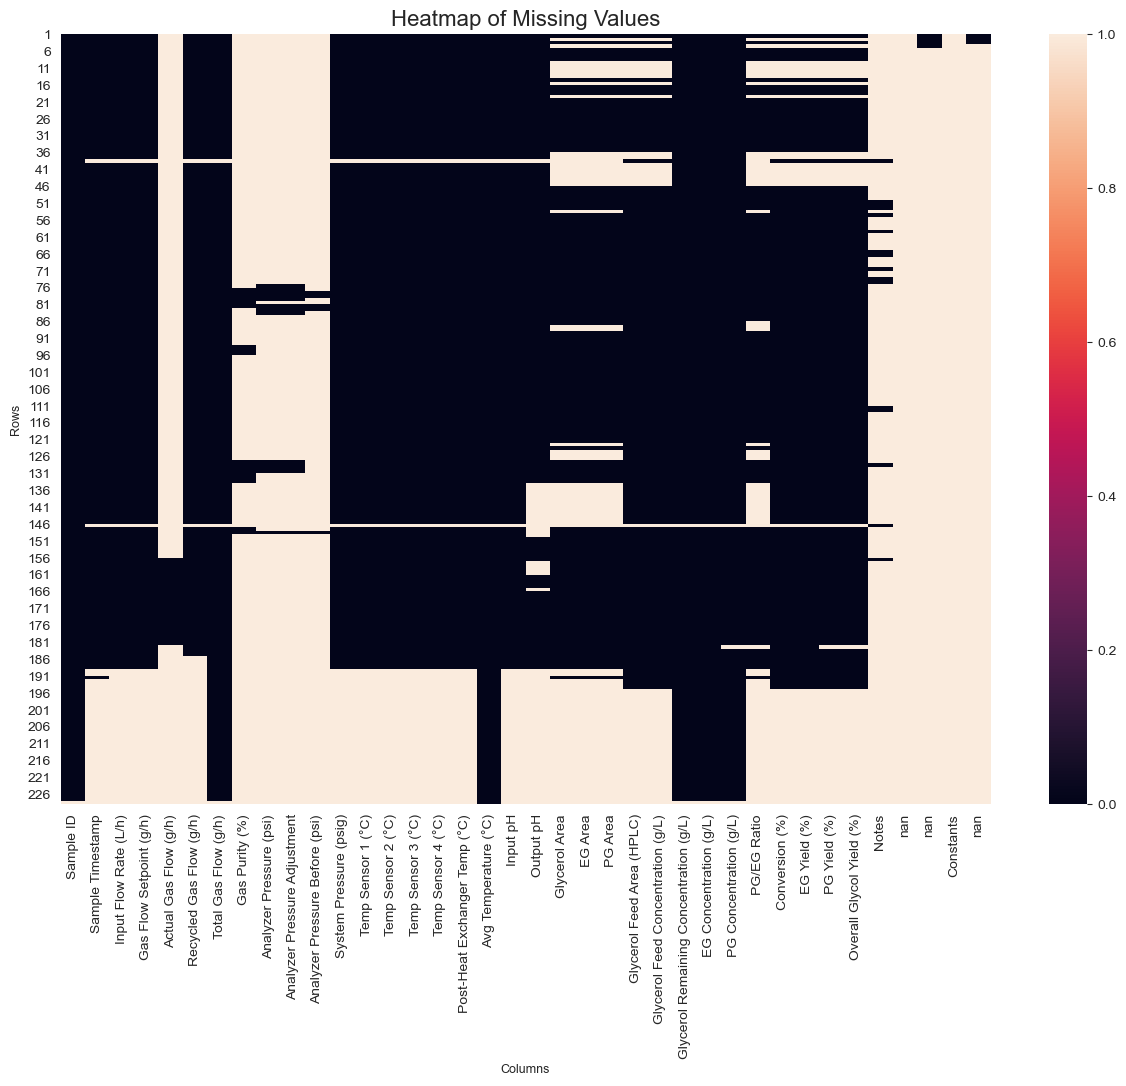

In [82]:
colors = ['#022c75', '#345ca8', '#7ea3d4', '#41991e', '#6bb334', '#a3d77f']

plt.figure(figsize=(15, 10))

sns.heatmap(hydrogen_df.isnull())

plt.title('Heatmap of Missing Values', fontsize=16)
plt.xlabel('Columns', fontsize=9)
plt.ylabel('Rows', fontsize=9)

plt.show()

Below, we are just filtering the rows with actual entries based on the presence of the unique identifier 'Glycerine to Glycol Sample ID'.

In [83]:
hydrogen_df = hydrogen_df[hydrogen_df['Sample ID'].notna()].iloc[:, :33]
# hydrogen_df.head()

Let us take a more numerical approach in order to observe the amount of missing data.

In [84]:
def check_missing_columns(df):
    missing_data = pd.DataFrame(df.isnull().sum())
    missing_data['Column'] = missing_data.index
    missing_data.columns = ['Missing Count', 'Column']

    missing_data['Missing Percentage'] = (missing_data['Missing Count'] / len(hydrogen_df)) * 100

    missing_data['Non-null Count'] = df.notnull().sum()
    missing_data['Type'] = df.dtypes

    missing_data.reset_index(drop=True, inplace=True)
    missing_data.sort_values(by='Missing Count', ascending=False, inplace=True)

    return missing_data[['Column', 'Type', 'Non-null Count', 'Missing Count', 'Missing Percentage']]


missing_columns = check_missing_columns(hydrogen_df)
missing_columns

,Column,Type,Non-null Count,Missing Count,Missing Percentage
10,Analyzer Pressure Before (psi),object,5,222,97.797357
9,Analyzer Pressure Adjustment,object,13,214,94.273128
8,Analyzer Pressure (psi),object,13,214,94.273128
7,Gas Purity (%),object,18,209,92.070485
4,Actual Gas Flow (g/h),object,26,201,88.546256
28,PG/EG Ratio,object,148,79,34.801762
20,Glycerol Area,object,150,77,33.920705
21,EG Area,object,150,77,33.920705
22,PG Area,object,150,77,33.920705
19,Output pH,object,166,61,26.872247


From the table above we can see that 5 columns have around 90% of their data missing, 4 columns with around 30%, 18 columns have around 20%, and finally the remaing columns have a few missing values.

### Handling missing values

Next, we will address the missing data by identifying and removing columns with more than 35% missing values. These columns are deemed unusable due to the significant amount of missing data, and the client has confirmed that these features are not critical for analysis.

In [85]:
column_to_drop = missing_columns.loc[missing_columns['Missing Percentage'] > 35, 'Column'].tolist()
column_to_drop

['Analyzer Pressure Before (psi)',
 'Analyzer Pressure Adjustment',
 'Analyzer Pressure (psi)',
 'Gas Purity (%)',
 'Actual Gas Flow (g/h)']

In [86]:
hydrogen_df = hydrogen_df.drop(column_to_drop, axis=1)

# hydrogen_df.head()

Similarly, we will remove rows with more than 50% missing data, as they are largely incomplete and unsuitable for meaningful analysis.

In [87]:
missing_percentage = hydrogen_df.isnull().mean(axis=1) * 100

missing_rows = pd.DataFrame({
    'Row Index': hydrogen_df.index,
    'Missing Percentage': missing_percentage
})

check_missing_rows = missing_rows.sort_values(by='Missing Percentage', ascending=False)

check_missing_rows

,Row Index,Missing Percentage
146,146,96.428571
227,227,78.571429
204,204,78.571429
212,212,78.571429
211,211,78.571429
...,...,...
92,92,0.000000
93,93,0.000000
94,94,0.000000
95,95,0.000000


In [88]:
rows_to_keep = missing_rows[missing_rows['Missing Percentage'] < 50]['Row Index']
hydrogen_df = hydrogen_df.loc[rows_to_keep]

In [89]:
hydrogen_df.shape

(187, 28)

We are now left with only 187 rows and 28 columns in total.

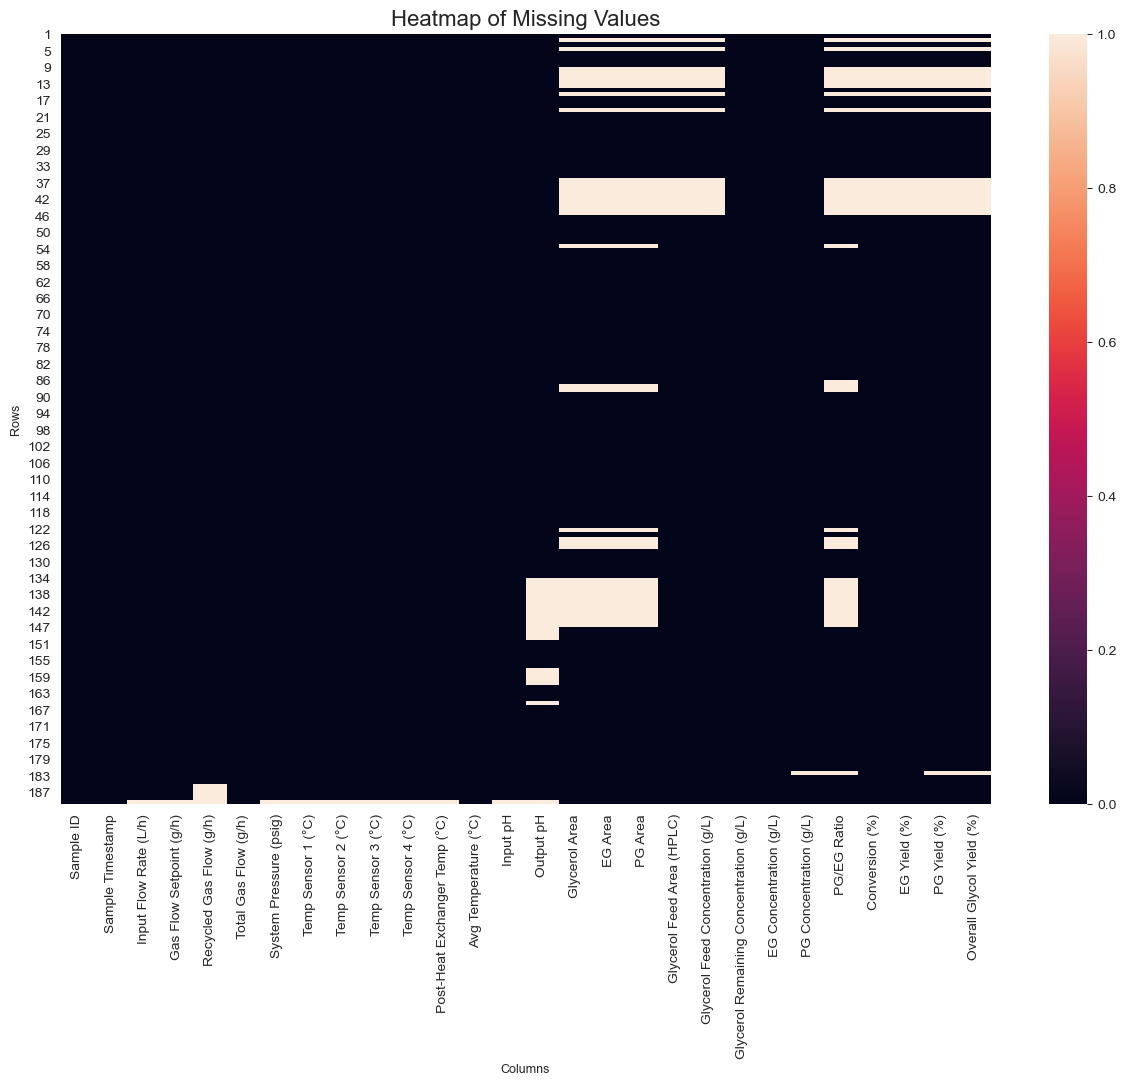

In [90]:
plt.figure(figsize=(15, 10))

sns.heatmap(hydrogen_df.isnull())

plt.title('Heatmap of Missing Values', fontsize=16)
plt.xlabel('Columns', fontsize=9)
plt.ylabel('Rows', fontsize=9)

plt.show()

The graph above, along with the numerical data below, shows a significant improvement in the amount of missing data. However, we note that some features are currently stored as object types instead of numerical values. We will apply the necessary transformations to address this later.

In [91]:
check_missing_columns(hydrogen_df)

,Column,Type,Non-null Count,Missing Count,Missing Percentage
23,PG/EG Ratio,object,148,39,20.855615
15,Glycerol Area,object,150,37,19.786096
17,PG Area,object,150,37,19.786096
16,EG Area,object,150,37,19.786096
14,Output pH,object,166,21,11.229947
26,PG Yield (%),object,168,19,10.160428
27,Overall Glycol Yield (%),object,168,19,10.160428
25,EG Yield (%),object,169,18,9.625668
24,Conversion (%),object,169,18,9.625668
19,Glycerol Feed Concentration (g/L),object,169,18,9.625668


### Transforming variables

As we have some errornous string values stored in place of numeric data, we convert them to NaN. Due to the presence of NaN and string values lie 'n/a', numeric columns are incorrectly classified as object. Additionally, a datetime column is stored as a string, which will require proper conversion.

In [92]:
hydrogen_df.iloc[:, 2:] = hydrogen_df.iloc[:, 2:].apply(
    lambda col: col.map(lambda x: np.nan if isinstance(x, str) else x)
)

In [93]:
exclude_columns = ['Sample ID', 'Sample Timestamp']

for column in hydrogen_df.columns:
    if column not in exclude_columns:
        hydrogen_df[column] = pd.to_numeric(hydrogen_df[column], errors='coerce')

In [94]:
hydrogen_df['Sample Timestamp'] = pd.to_datetime(hydrogen_df['Sample Timestamp'])

### Imputing the data using KNN

Although we have addressed many of the rows and columns with missing data, a considerable amount still remains. One strategy we can employ to deal with this is to impute the data.

However, the challenge lies in determining the most appropriate method of imputation to minimize any significant impact on our analysis. To address this, we will use the k-Nearest Neighbors (k-NN) algorithm, a clustering technique that considers all features simultaneously. This method imputes missing values based on the nearest neighbors of each data point, ensuring that the imputed values closely align with what is expected.

In [95]:
exclude_columns = ['Sample ID', 'Sample Timestamp']

numerical_df = hydrogen_df.drop(columns=exclude_columns, axis=1)

imputer = KNNImputer(n_neighbors=2, weights='distance', metric='nan_euclidean')

In [96]:
imputed_df = pd.DataFrame(imputer.fit_transform(numerical_df), columns=numerical_df.columns)

cleaned_df = hydrogen_df.reset_index(drop=True)
imputed_df = imputed_df.reset_index(drop=True)

In [97]:
imputed_df = pd.concat([cleaned_df[exclude_columns], imputed_df], axis=1)

# imputed_df.head()

In [98]:
check_missing_columns(imputed_df)

,Column,Type,Non-null Count,Missing Count,Missing Percentage
0,Sample ID,object,187,0,0.0
1,Sample Timestamp,datetime64[ns],187,0,0.0
26,PG Yield (%),float64,187,0,0.0
25,EG Yield (%),float64,187,0,0.0
24,Conversion (%),float64,187,0,0.0
23,PG/EG Ratio,float64,187,0,0.0
22,PG Concentration (g/L),float64,187,0,0.0
21,EG Concentration (g/L),float64,187,0,0.0
20,Glycerol Remaining Concentration (g/L),float64,187,0,0.0
19,Glycerol Feed Concentration (g/L),float64,187,0,0.0


### Checking the difference between the original & imputed data

Although we imputed the data, we need to make sure that such imputation has not significantly affected the data too much.

In [99]:
imputed_num_df = imputed_df.drop(columns=exclude_columns, axis=1)

non_missing_mask = numerical_df.notna()

differences = (imputed_num_df - numerical_df)[non_missing_mask]

mean_abs_diff = differences.abs().mean().mean()
print(f"Mean Absolute Difference for non-missing values: {mean_abs_diff}")

Mean Absolute Difference for non-missing values: 85.11137224648867


In [100]:
original_mean = numerical_df[non_missing_mask].mean().mean()
relative_mad = (mean_abs_diff / original_mean) * 100

print(f"Relative Mean Absolute Difference: {relative_mad:.2f}%")

Relative Mean Absolute Difference: 11.40%


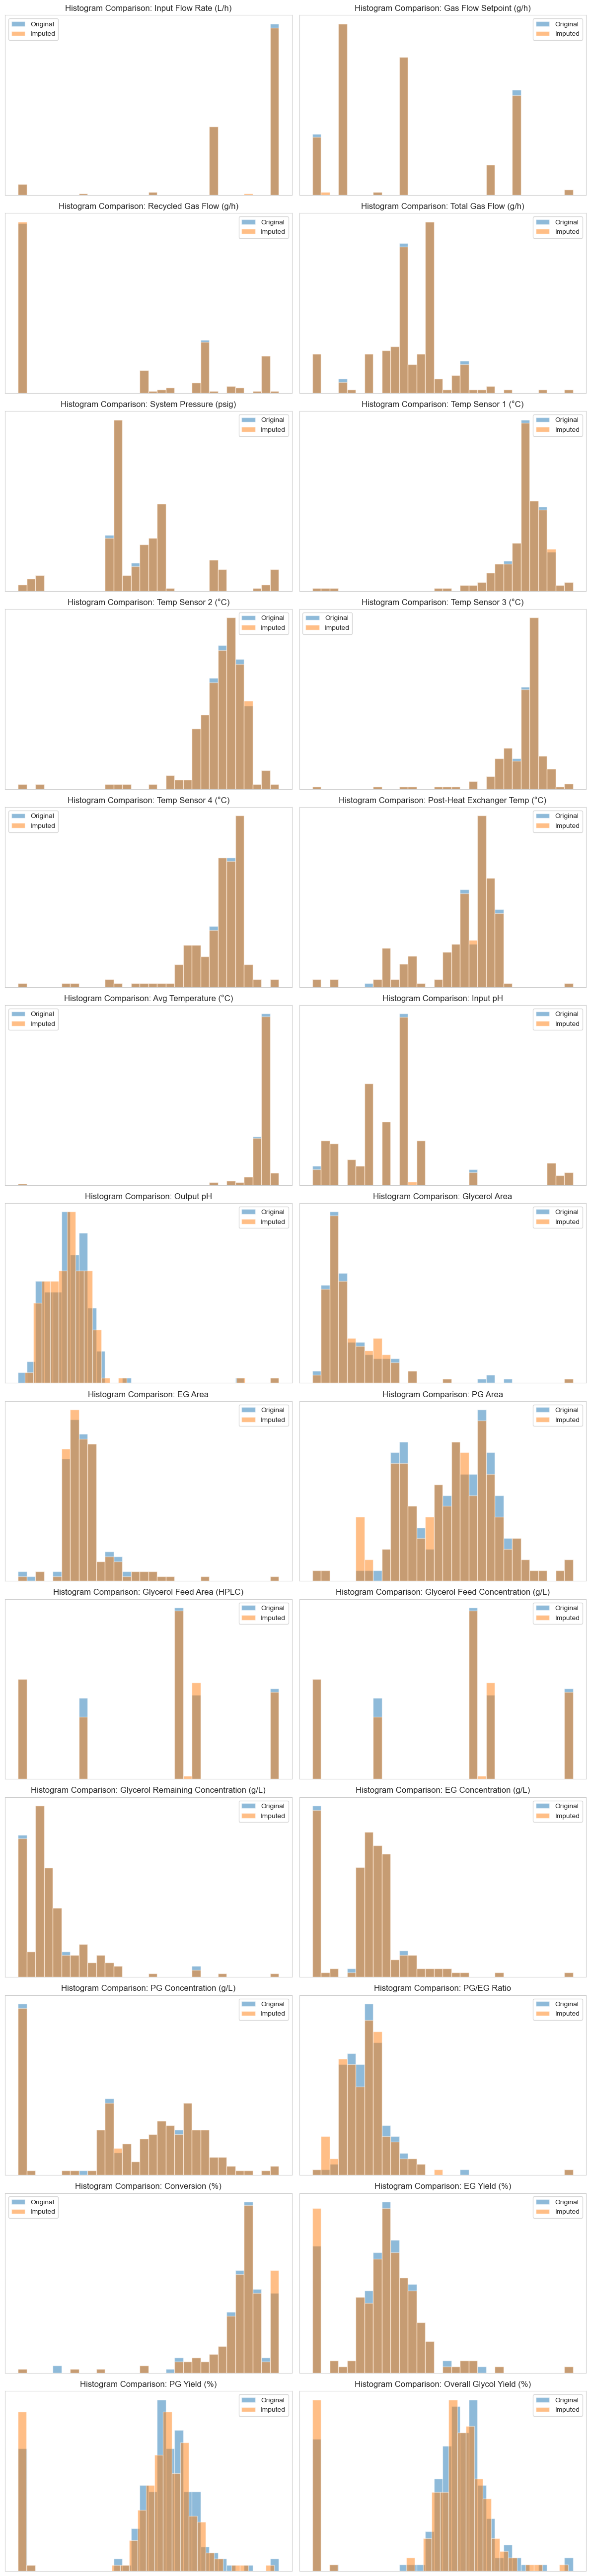

In [101]:
original_non_missing = numerical_df[non_missing_mask]
imputed_non_missing = imputed_df[non_missing_mask]

cols = 2
num_columns = len(numerical_df.columns)
rows = math.ceil(num_columns / cols)
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

for i, column in enumerate(numerical_df.columns):
    axes[i].hist(original_non_missing[column].dropna(), bins=30, alpha=0.5, label='Original')
    axes[i].hist(imputed_non_missing[column].dropna(), bins=30, alpha=0.5, label='Imputed')
    axes[i].set_title(f'Histogram Comparison: {column}')
    axes[i].legend()

    # Hide axes
    axes[i].set_xticks([])
    axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The graphs above clearly illustrate the extent to which the newly added data has impacted each column. A relative mean absolute difference of 11.24% suggests a noticeable, yet not overly significant alteration in the dataset as a result of the imputation process.

### Using the original dataframe without imputation

We want to carry out analysis in both imputed data and original data. However, in order to perform analysis on the original data, we need to first clean it of missing values to make it suitable for machine learning tasks. To achieve this, we tentatively remove all rows with missing values and create a cleaned dataframe for further analysis.

In [102]:
hydrogen_df = hydrogen_df.dropna()
numerical_df = numerical_df.dropna()

In [103]:
check_missing_columns(numerical_df)

,Column,Type,Non-null Count,Missing Count,Missing Percentage
0,Input Flow Rate (L/h),float64,135,0,0.0
1,Gas Flow Setpoint (g/h),float64,135,0,0.0
24,PG Yield (%),float64,135,0,0.0
23,EG Yield (%),float64,135,0,0.0
22,Conversion (%),float64,135,0,0.0
21,PG/EG Ratio,float64,135,0,0.0
20,PG Concentration (g/L),float64,135,0,0.0
19,EG Concentration (g/L),float64,135,0,0.0
18,Glycerol Remaining Concentration (g/L),float64,135,0,0.0
17,Glycerol Feed Concentration (g/L),float64,135,0,0.0


## EXPLORATORY DATA ANALYSIS (EDA)

We now perform preliminary EDA to identify errors, inconsistencies, and unusual patterns in the data. This process helps us better understand the dataset's structure and characteristics.

### Correlation matrix for original cleaned data

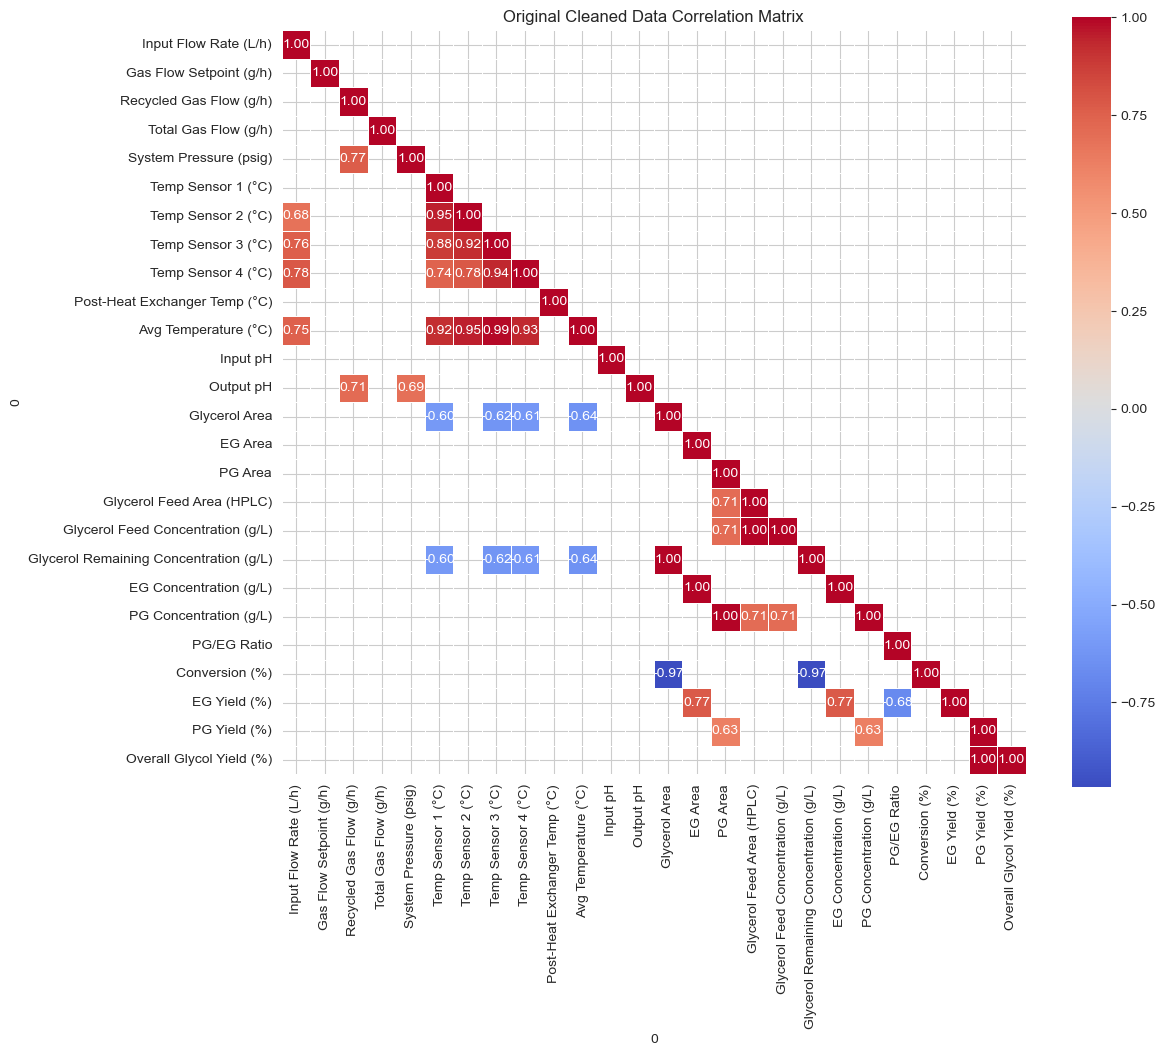

In [104]:
corr = numerical_df.corr()
corr_filtered = corr.where((corr > 0.60) | (corr < -0.60))
mask = np.triu(np.ones_like(corr, dtype=bool))
np.fill_diagonal(mask, False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_filtered, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=0.5, mask=mask)
plt.title('Original Cleaned Data Correlation Matrix')
plt.show()

In [105]:
corr

,Input Flow Rate (L/h),Gas Flow Setpoint (g/h),Recycled Gas Flow (g/h),Total Gas Flow (g/h),System Pressure (psig),Temp Sensor 1 (°C),Temp Sensor 2 (°C),Temp Sensor 3 (°C),Temp Sensor 4 (°C),Post-Heat Exchanger Temp (°C),...,Glycerol Feed Area (HPLC),Glycerol Feed Concentration (g/L),Glycerol Remaining Concentration (g/L),EG Concentration (g/L),PG Concentration (g/L),PG/EG Ratio,Conversion (%),EG Yield (%),PG Yield (%),Overall Glycol Yield (%)
0,,,,,,,,,,,,,,,,,,,,,
Input Flow Rate (L/h),1.000000,0.115264,-0.018923,-0.005732,0.148896,0.570657,0.682885,0.760502,0.777455,-0.240329,...,-0.107659,-0.107692,-0.477765,0.293810,0.268955,-0.279286,0.408000,0.283752,0.334902,0.349051
Gas Flow Setpoint (g/h),0.115264,1.000000,-0.364277,-0.132211,-0.470941,-0.163963,-0.125554,-0.076012,-0.062039,-0.112127,...,-0.082932,-0.082979,0.198903,-0.197849,-0.174755,0.022540,-0.242154,-0.081386,0.044947,0.033802
Recycled Gas Flow (g/h),-0.018923,-0.364277,1.000000,0.114935,0.765508,-0.219070,-0.141940,-0.046647,0.037766,-0.198732,...,0.441346,0.441440,0.169569,0.120820,0.409978,0.253969,-0.083852,-0.101026,0.312049,0.285336
Total Gas Flow (g/h),-0.005732,-0.132211,0.114935,1.000000,0.079119,0.197449,0.229115,0.101438,-0.035443,-0.034474,...,-0.459149,-0.459105,-0.091420,-0.111342,-0.366204,-0.205395,0.005072,0.110043,-0.161840,-0.141692
System Pressure (psig),0.148896,-0.470941,0.765508,0.079119,1.000000,-0.012068,0.095968,0.145377,0.176202,-0.139959,...,0.261428,0.261497,-0.031883,0.254494,0.437031,0.053677,0.081120,0.071801,0.387053,0.375439
Temp Sensor 1 (°C),0.570657,-0.163963,-0.219070,0.197449,-0.012068,1.000000,0.950916,0.878268,0.742080,0.255979,...,-0.406294,-0.406309,-0.602577,0.207430,0.002050,-0.338031,0.511186,0.319072,0.084477,0.115068
Temp Sensor 2 (°C),0.682885,-0.125554,-0.141940,0.229115,0.095968,0.950916,1.000000,0.921719,0.783422,0.132966,...,-0.460293,-0.460306,-0.585523,0.231328,0.024930,-0.399626,0.472264,0.383001,0.210241,0.241491
Temp Sensor 3 (°C),0.760502,-0.076012,-0.046647,0.101438,0.145377,0.878268,0.921719,1.000000,0.935191,0.123845,...,-0.193179,-0.193192,-0.624159,0.315821,0.278157,-0.299754,0.552812,0.320875,0.326391,0.345021
Temp Sensor 4 (°C),0.777455,-0.062039,0.037766,-0.035443,0.176202,0.742080,0.783422,0.935191,1.000000,0.035891,...,0.066226,0.066212,-0.611742,0.390477,0.480765,-0.233629,0.590174,0.247146,0.376491,0.384553


Below are the insights that we have gained from the correlation matrix above.

1. All temps (T3,T2,etc.) are highly correlated which are to be expected.

2. Liquid feed has moderate correlation with T3 (0.68) but increases progressively, the highest being T5(0.78).

3. Recycled H2 gas flow has high correlation with Rx pressure and product pH.

4. RX pressure has moderate correlation with product pH.

5. Avg. temp has high correlation with liquid feed (0.75) and the temp features, with it increasing upto 0.99 at T4 and going down at T5 to 0.93. It also has a moderate negative correlation with glycerol remaining concentration and glycerol area.

8. Product pH has a positive high correlation with recycled H2 flow(0.71) and Rx pressure(0.69).

In [106]:
strong_threshold = 0.6
very_strong_threshold = 0.8
moderate_threshold = 0.4

correlation_results = {}

for column in corr.columns:
    correlations = {}
    for other_column in corr.columns:
        if column != other_column:
            value = corr[column][other_column]
            if abs(value) >= very_strong_threshold:
                correlations[other_column] = (value, 'Very Strong')
            elif abs(value) >= strong_threshold:
                correlations[other_column] = (value, 'Strong')
            elif abs(value) >= moderate_threshold:
                correlations[other_column] = (value, 'Moderate')

    if correlations:
        correlation_results[column] = correlations

for col, correlations in correlation_results.items():
    print(f"{col}:")
    for other_col, (value, strength) in correlations.items():
        print(f"  - {other_col}: {strength} correlation ({value:.2f})")

Input Flow Rate (L/h):
  - Temp Sensor 1 (°C): Moderate correlation (0.57)
  - Temp Sensor 2 (°C): Strong correlation (0.68)
  - Temp Sensor 3 (°C): Strong correlation (0.76)
  - Temp Sensor 4 (°C): Strong correlation (0.78)
  - Avg Temperature (°C): Strong correlation (0.75)
  - Glycerol Area: Moderate correlation (-0.48)
  - Glycerol Remaining Concentration (g/L): Moderate correlation (-0.48)
  - Conversion (%): Moderate correlation (0.41)
Gas Flow Setpoint (g/h):
  - System Pressure (psig): Moderate correlation (-0.47)
Recycled Gas Flow (g/h):
  - System Pressure (psig): Strong correlation (0.77)
  - Output pH: Strong correlation (0.71)
  - PG Area: Moderate correlation (0.41)
  - Glycerol Feed Area (HPLC): Moderate correlation (0.44)
  - Glycerol Feed Concentration (g/L): Moderate correlation (0.44)
  - PG Concentration (g/L): Moderate correlation (0.41)
Total Gas Flow (g/h):
  - Glycerol Feed Area (HPLC): Moderate correlation (-0.46)
  - Glycerol Feed Concentration (g/L): Moderate

These results are slightly deceptive as it is only taking into account the linear correlation between the features when the might have non-linear correlation present. Due to this we create a scatter plot below to observe this phenomenon and see the linearity of each relationships.



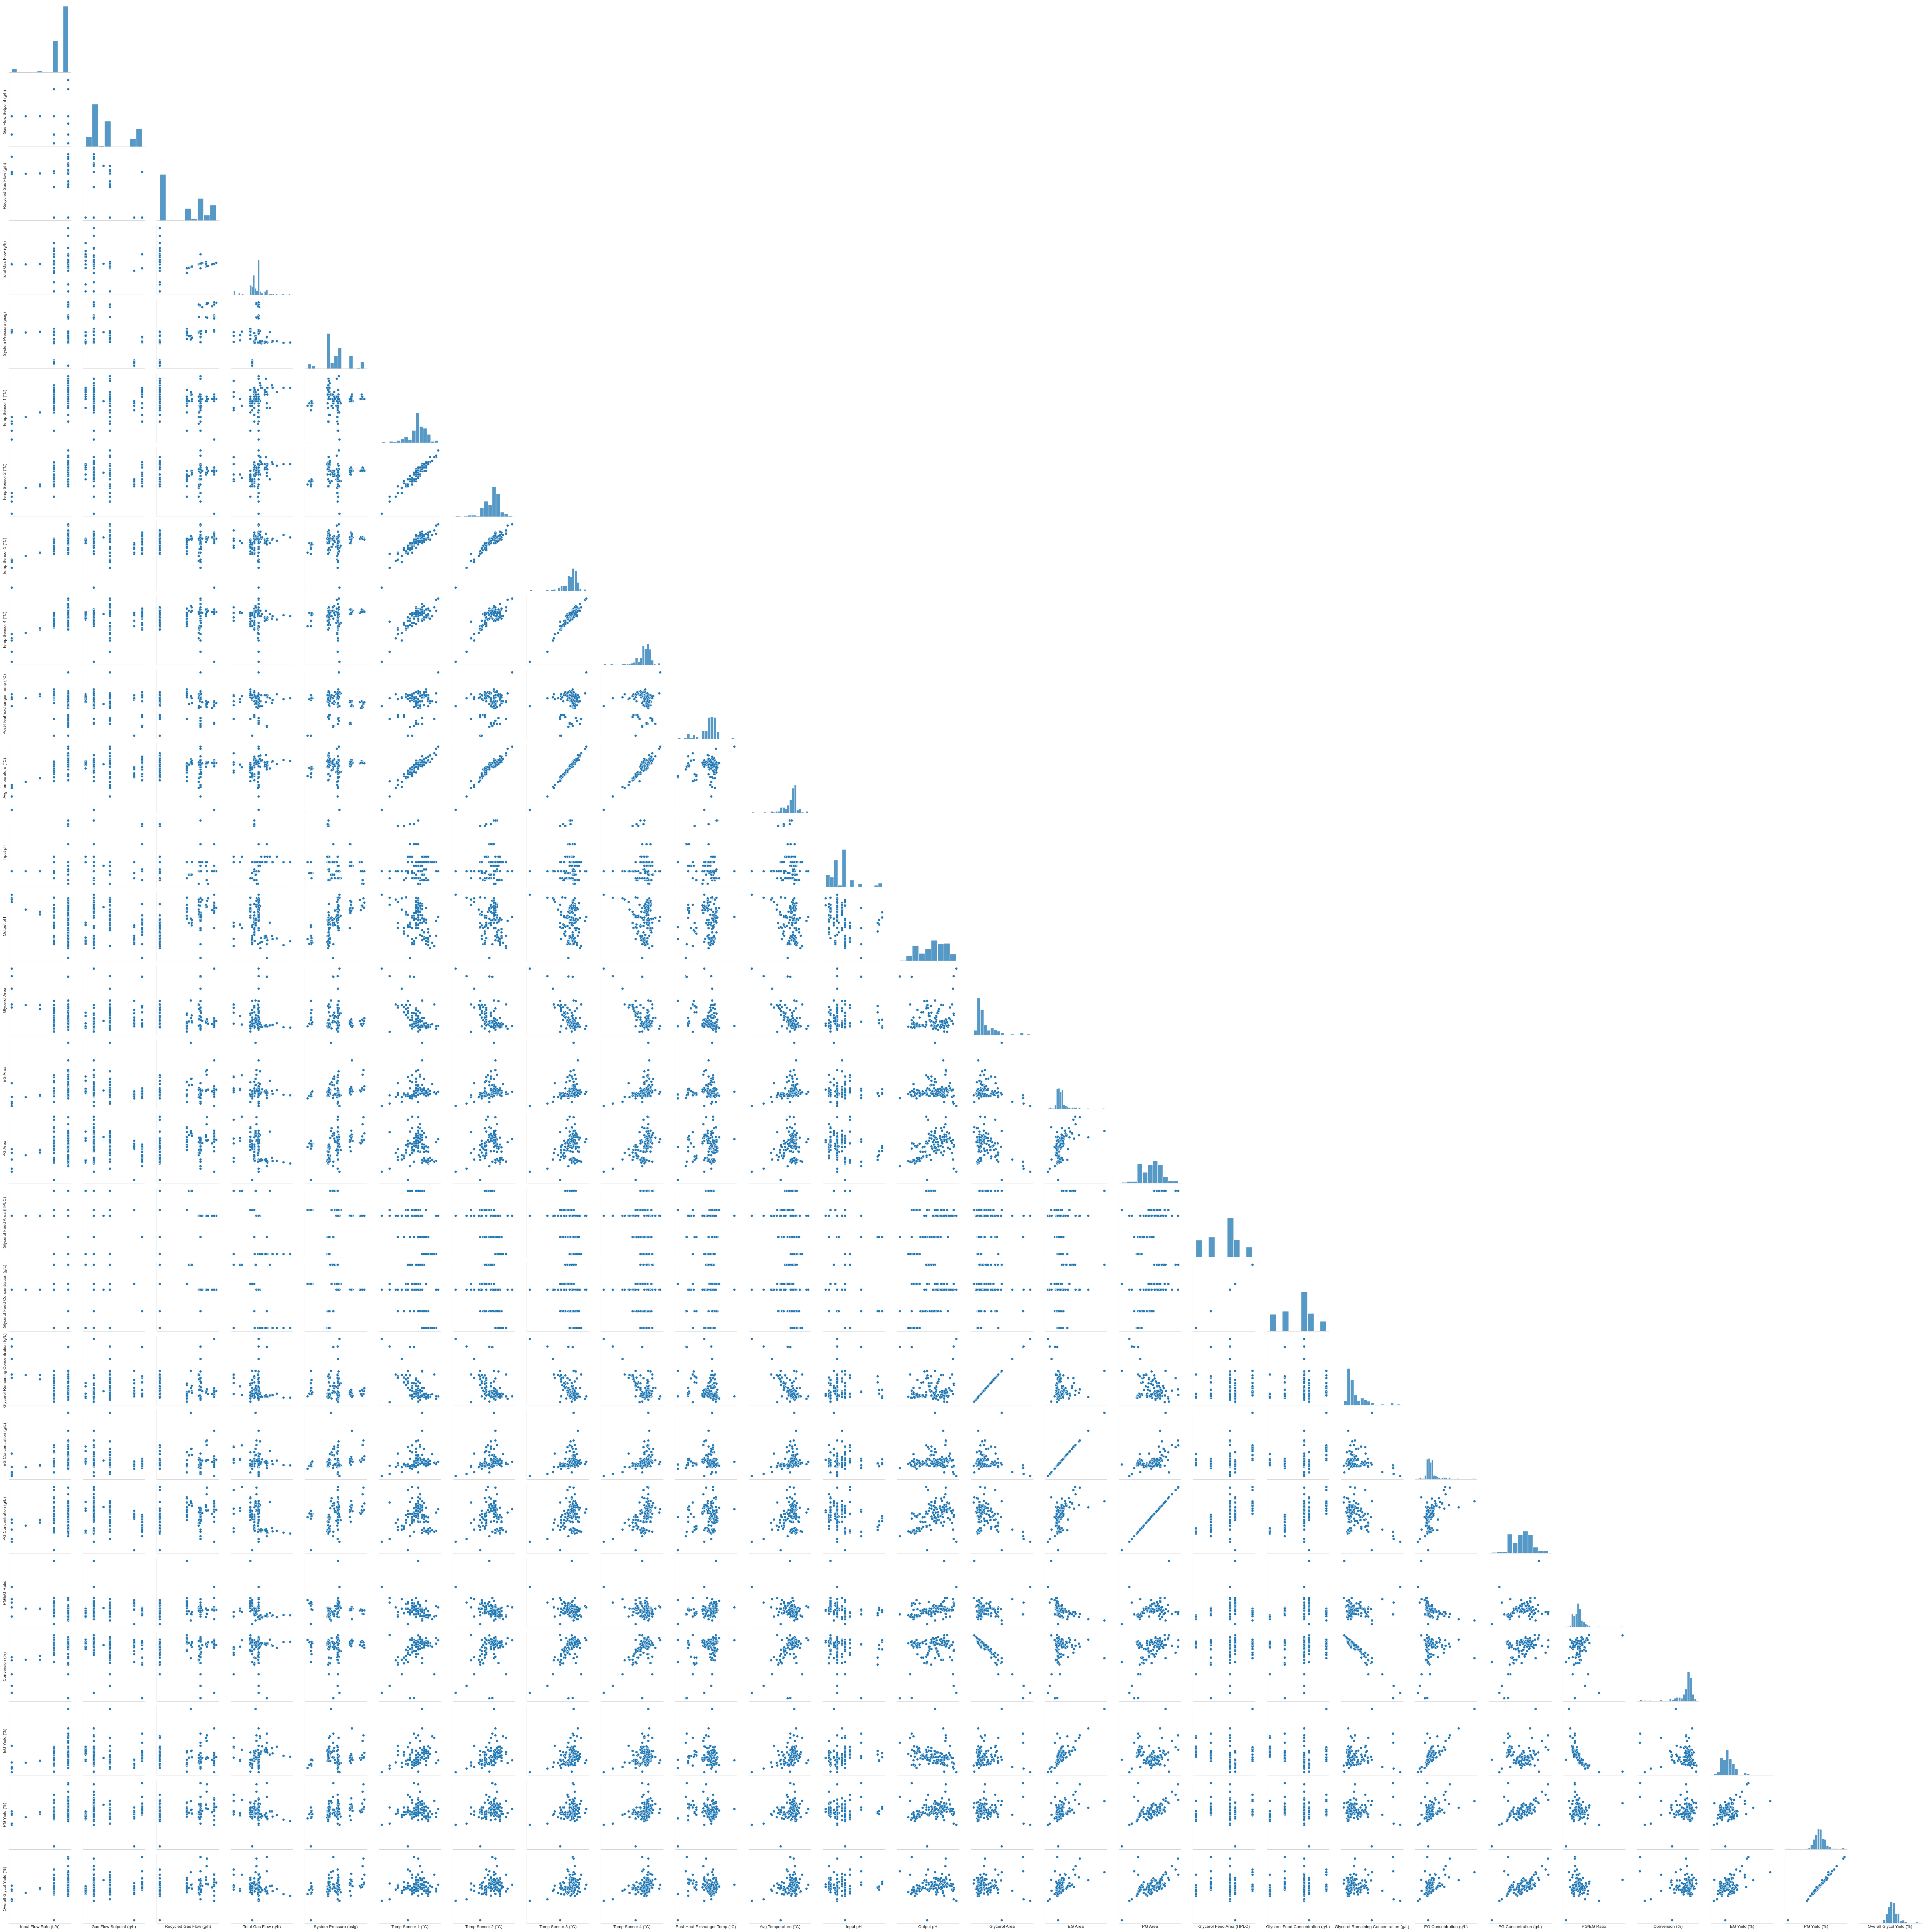

In [107]:
g = sns.pairplot(numerical_df, diag_kind='hist', corner=True)

# Hide axes
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()

As we can see there is the presence of non-linear correlations between many of the features as well as linear ones. We observe that the following performance metrics are calculated from the other columns which causes linearity and high correlation: 'Glycerol Remaining Concentration (g/L)', 'EG Concentration (g/L)', 'PG Concentration (g/L)', 'PG/EG Ratio', 'Conversion (%)', 'EG Yield (%)', 'PG Yield (%)', 'Overall Glycol Yield (%)'. So, we can remove these features without loosing any relevant information.

In [108]:
calculated_columns = [
    'Glycerol Remaining Concentration (g/L)',
    'EG Concentration (g/L)',
    'PG Concentration (g/L)',
    'PG/EG Ratio',
    'Conversion (%)',
    'EG Yield (%)',
    'PG Yield (%)',
    'Overall Glycol Yield (%)'
]

no_calc_df = numerical_df.drop(columns=calculated_columns, axis=1)
no_calc_df.head()

,Input Flow Rate (L/h),Gas Flow Setpoint (g/h),Recycled Gas Flow (g/h),Total Gas Flow (g/h),System Pressure (psig),Temp Sensor 1 (°C),Temp Sensor 2 (°C),Temp Sensor 3 (°C),Temp Sensor 4 (°C),Post-Heat Exchanger Temp (°C),Avg Temperature (°C),Input pH,Output pH,Glycerol Area,EG Area,PG Area,Glycerol Feed Area (HPLC),Glycerol Feed Concentration (g/L)
1,4.0,250.0,150.0,400,631.0,216.0,219.0,221.0,223.0,227.0,219.75,11.30,3.56,4989.8352,133.1288,2472.0252,7670.7621,581.443767
3,4.0,250.0,150.0,400,633.0,218.0,221.0,225.0,223.0,228.0,221.75,11.30,3.95,4964.9267,169.5690,3141.5480,7670.7621,581.443767
5,4.0,250.0,0.0,250,606.0,210.0,213.0,214.0,214.0,239.0,212.75,11.15,4.43,2230.2661,171.5486,3831.9028,7670.7621,581.443767
6,4.0,250.0,0.0,250,613.0,213.0,215.0,216.0,217.0,239.0,215.25,11.10,4.43,2287.2788,195.1234,3985.3366,7670.7621,581.443767
7,4.0,250.0,0.0,250,606.0,213.0,216.0,217.0,218.0,239.0,216.00,11.10,4.26,1827.1403,181.5832,3597.2832,7670.7621,581.443767


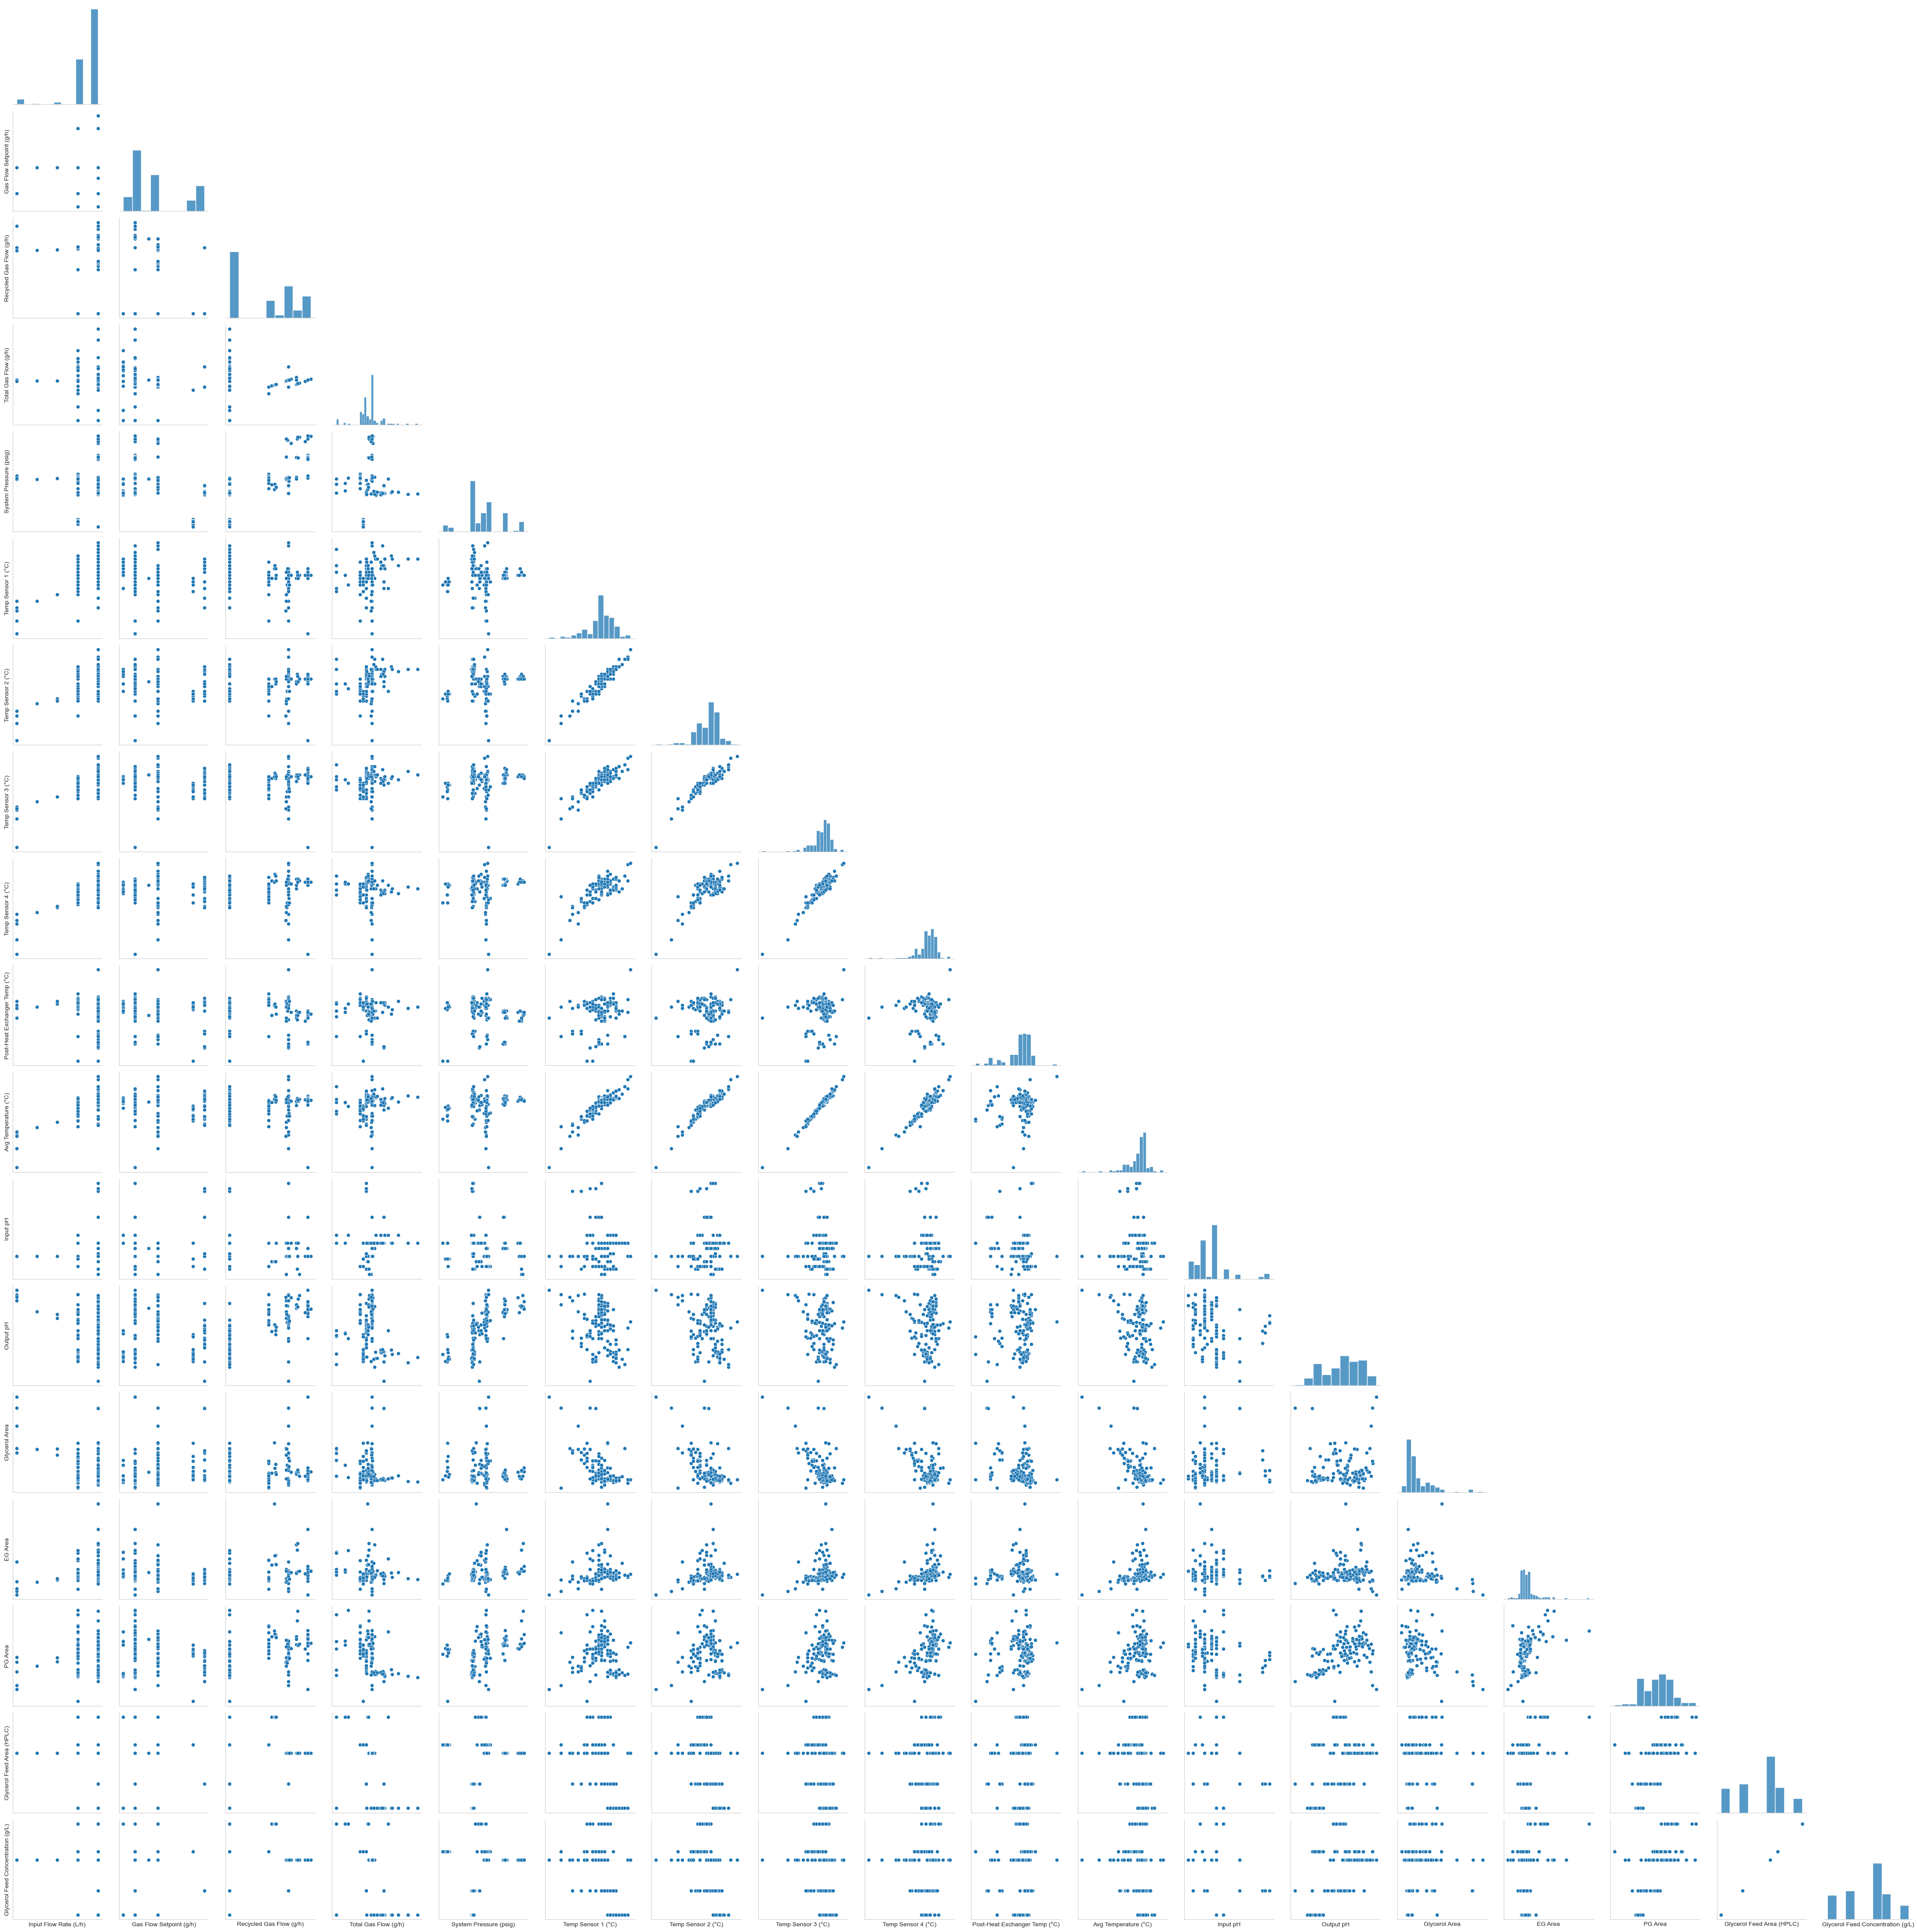

In [109]:
h = sns.pairplot(no_calc_df, diag_kind='hist', corner=True)

# Hide axes
for ax in h.axes.flatten():
    if ax is not None:
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()

### Correlation matrix for original cleaned data with non-calculated features

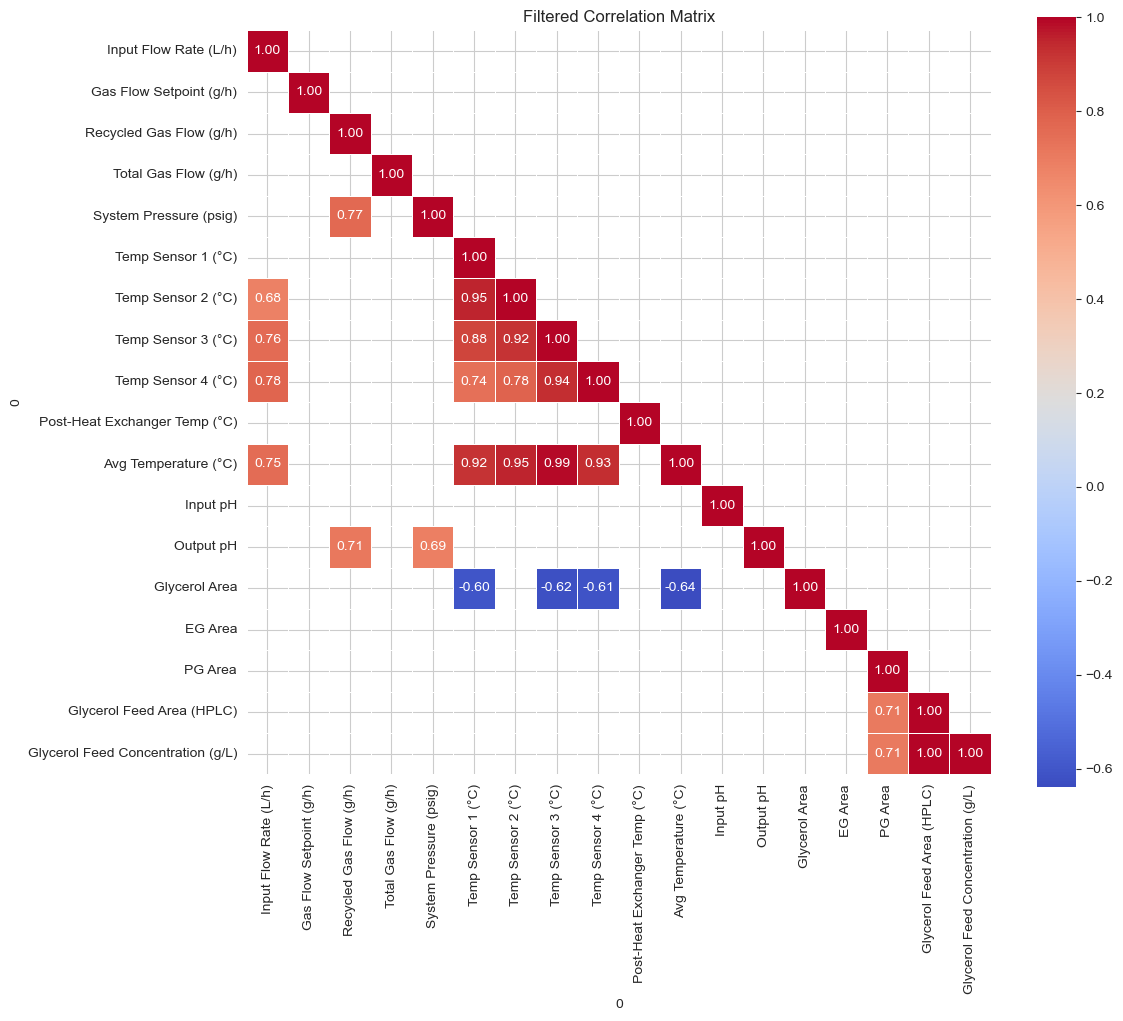

In [110]:
corr = no_calc_df.corr()
corr_filtered = corr.where((corr > 0.60) | (corr < -0.60))
mask = np.triu(np.ones_like(corr, dtype=bool))
np.fill_diagonal(mask, False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_filtered, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=0.5, mask=mask)
plt.title('Filtered Correlation Matrix')
plt.show()

### Histogram for all features

Similar to the correlation matrix and scatter plot matrix above, we will now look at the histograms of all the features to see how the data in each column is distributed.

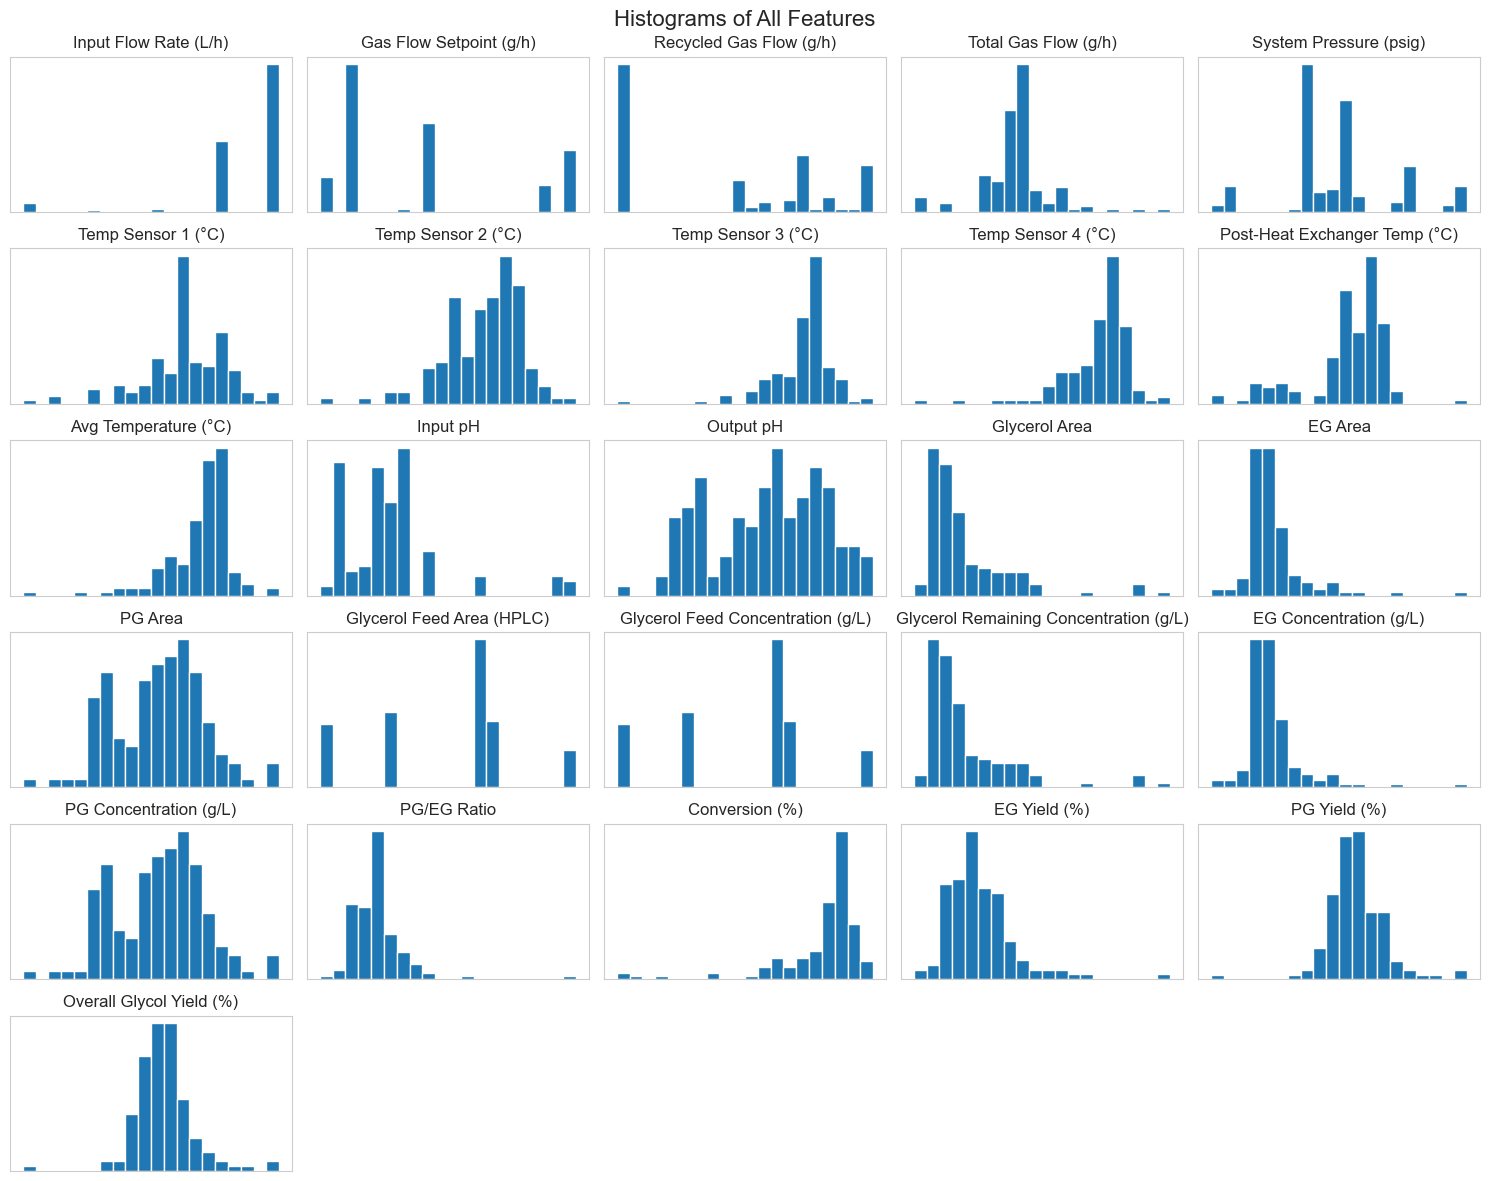

In [111]:
i = numerical_df.hist(figsize=(15, 12), bins=20, grid=False)

for ax in i.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Histograms of All Features", fontsize=16)
plt.tight_layout()
plt.show()

In general, many of the data are multimodal meaning they have a few distinct values that they can take. Some are bell shaped meaning most values are within a certain expected range. Some are left (majority of data lie on the right side) or right (majority of data are clustered on the left side) skewed.

1. Input Flow Rate (L/h): The histogram shows a highly concentrated distribution, with most values clustered around [redacted] L/h, suggesting limited variability in liquid feed flow.

2. Gas Flow Setpoint on PLC (g/h): Values seem to be spread across a range, with peaks around specific values like [redacted] g/h. This indicates that the setpoints may have been adjusted or varied for different conditions.

3. Recycled Gas Flow (g/h): Similar to the gas flow setpoint, this feature has multiple peaks, reflecting controlled process adjustments and recycling operations.

4. Total Gas Flow (g/h): The distribution is concentrated in between the range of [redacted] g/h flow rates.

5. System Pressure (psig): A single prominent peak indicates a tightly controlled operating pressure with minimal deviation.

6. Temperatures: Temperature measurements across different points in the system display approximately normal distributions, with slight variation among sensor locations.

7. Average Temperature (°C): Has an approximately normal distribution centered around [redacted] °C, suggesting that the process maintains a consistent average temperature.

8. Input pH: The feed pH has a distinct peak, suggesting the feed is generally within a specific pH range (around [redacted]).

9. Output pH: Product pH values vary more widely, indicating potential fluctuations in the final product’s acidity or alkalinity, which could affect product quality.

10. Glycerol Area and Feed Area (HPLC): Glycerol area has a concentration of lower values, while feed area shows distinct peaks, indicating variable glycerol levels in feed over time.

11. Concentrations (Glycerol Feed, Remaining Glycerol, EG, PG):

    * Glycerol Feed Concentration: Shows a few distinct levels, possibly indicating step changes in feed concentration.
    * Glycerol Remaining Concentration: Mostly low values, suggesting efficient conversion or usage of glycerol.
    * EG Concentration and PG Concentration: EG has low levels with distinct spikes, while PG has a broader distribution, indicating higher PG levels than EG, reflecting the main product of the process.
    * PG/EG Ratio: This ratio has a broader distribution, showing variations in the range of [redacted].

12. Conversion (%): The histogram for conversion is heavily skewed toward higher values, indicating that the process generally achieves a high conversion rate.

13. Yields (EG Yield, PG Yield, Overall Glycol Yield):

    * EG Yield: Concentrated at low values, suggesting that EG is a minor product.
    * PG Yield: Shows a broader distribution with values between [redacted], indicating efficient production.
    * Overall Glycol Yield: Also concentrated at high values, suggesting efficient glycol yield from the process.

### Box and whisker plot for all features

Similar to the above analysis, we will now look at the box plot of all the features to gain more insights into the data of each column.

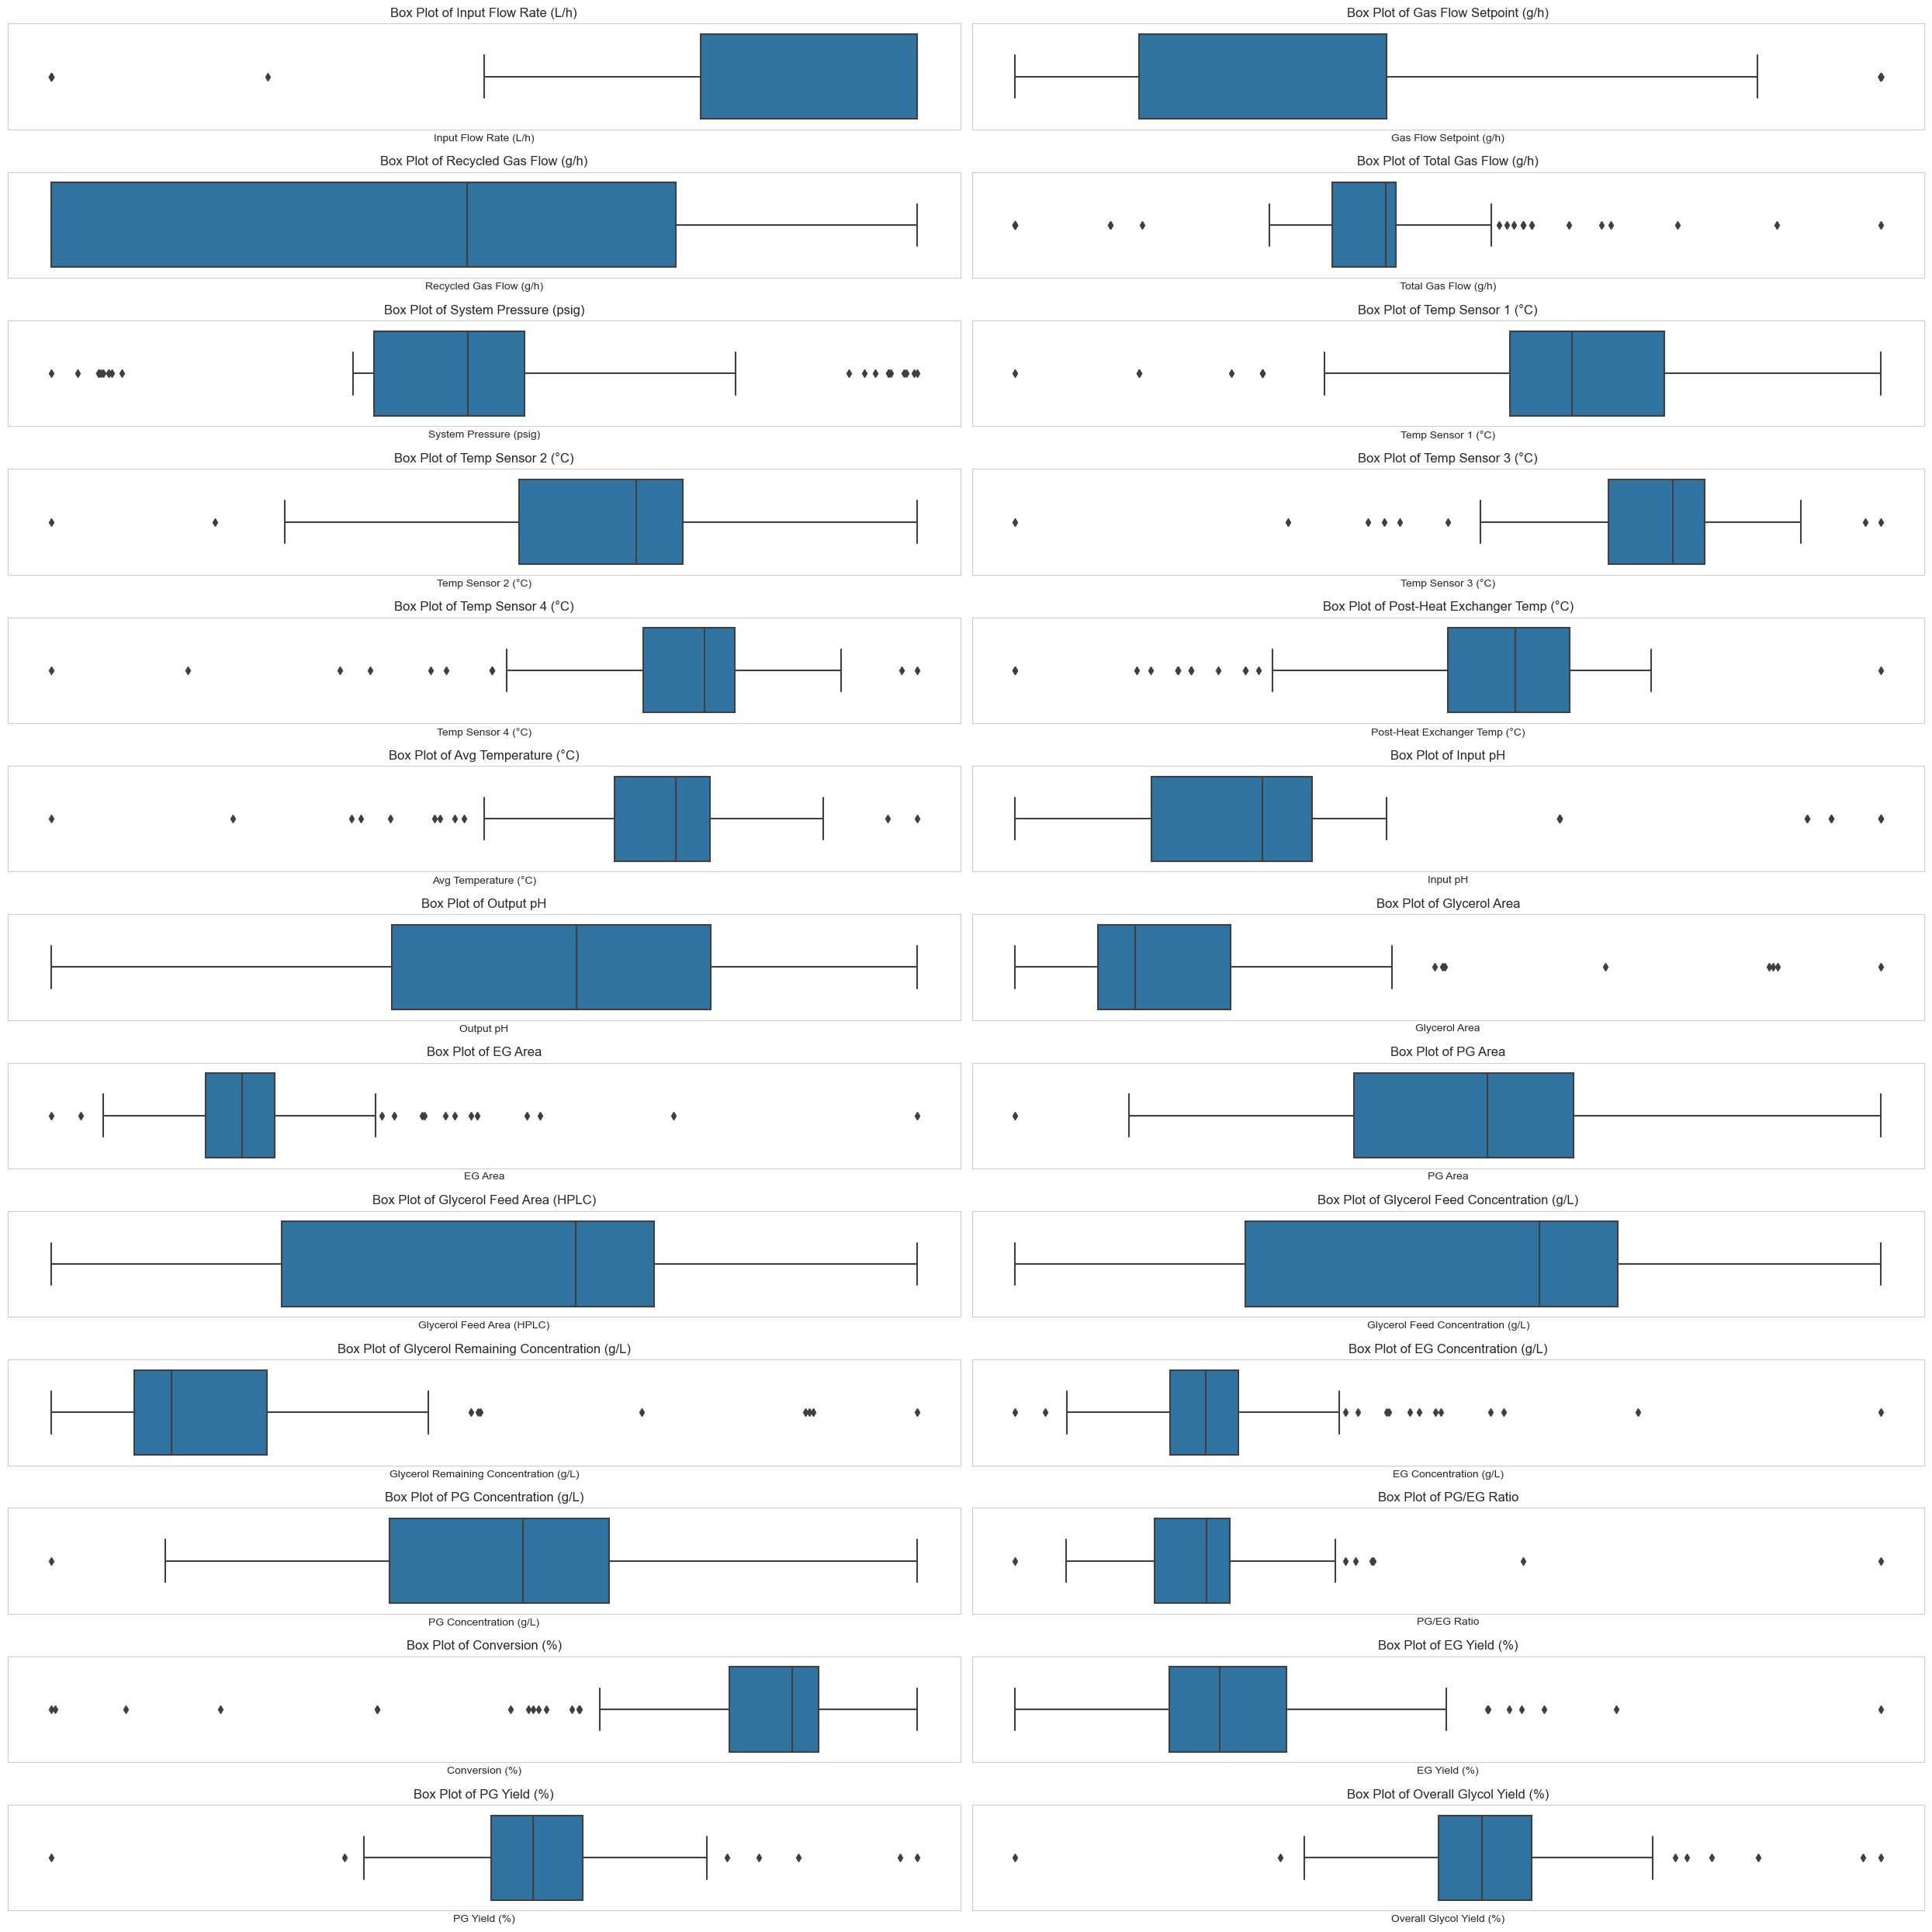

In [112]:
fig, axes = plt.subplots(13, 2, figsize=(25, 25))

axes = axes.flatten()

for i, col in enumerate(numerical_df):
    sns.boxplot(x=numerical_df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

    # Hide axes
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

* Many features show tight distributions, especially for temperatures and pressure, indicating controlled operational conditions. Outliers suggest occasional adjustments or process deviations.

* High conversion and yield metrics show an efficient process, though outliers in conversion and yield indicate periodic inefficiencies.

* Product pH and concentration measurements show more variability in product output, likely due to the nature of the reactions and variations in raw material composition or process adjustments.

## Outliers

When observing the box plots above, we can clearly see the presence of a lot of outliers in most of the columns. These will need to be handled in order to create better machine learning models.

In general, outliers are handle by either removing them, imputing them with the median or capping/replacing with the min/max values. In our case as even the outliers convey important information, we have opted to keep them as is. Below are just some of the features with outliers we intend to keep.

In [113]:
Q1 = numerical_df['Output pH'].quantile(0.25)
Q3 = numerical_df['Output pH'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = numerical_df[(numerical_df['Output pH'] < lower_bound) | (numerical_df['Output pH'] > upper_bound)]
outliers.head()

,Input Flow Rate (L/h),Gas Flow Setpoint (g/h),Recycled Gas Flow (g/h),Total Gas Flow (g/h),System Pressure (psig),Temp Sensor 1 (°C),Temp Sensor 2 (°C),Temp Sensor 3 (°C),Temp Sensor 4 (°C),Post-Heat Exchanger Temp (°C),...,Glycerol Feed Area (HPLC),Glycerol Feed Concentration (g/L),Glycerol Remaining Concentration (g/L),EG Concentration (g/L),PG Concentration (g/L),PG/EG Ratio,Conversion (%),EG Yield (%),PG Yield (%),Overall Glycol Yield (%)


In [114]:
Q1 = numerical_df['Input pH'].quantile(0.25)
Q3 = numerical_df['Input pH'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = numerical_df[(numerical_df['Input pH'] < lower_bound) | (numerical_df['Input pH'] > upper_bound)]
outliers.head()

,Input Flow Rate (L/h),Gas Flow Setpoint (g/h),Recycled Gas Flow (g/h),Total Gas Flow (g/h),System Pressure (psig),Temp Sensor 1 (°C),Temp Sensor 2 (°C),Temp Sensor 3 (°C),Temp Sensor 4 (°C),Post-Heat Exchanger Temp (°C),...,Glycerol Feed Area (HPLC),Glycerol Feed Concentration (g/L),Glycerol Remaining Concentration (g/L),EG Concentration (g/L),PG Concentration (g/L),PG/EG Ratio,Conversion (%),EG Yield (%),PG Yield (%),Overall Glycol Yield (%)
1,4.0,250.0,150.0,400,631.0,216.0,219.0,221.0,223.0,227.0,...,7670.7621,581.443767,378.229508,13.219690,208.391724,15.763738,0.349499,0.065053,1.025478,1.090531
3,4.0,250.0,150.0,400,633.0,218.0,221.0,225.0,223.0,228.0,...,7670.7621,581.443767,376.341444,16.838202,264.832496,15.728075,0.352747,0.082097,1.291221,1.373318
8,4.0,250.0,0.0,250,606.0,213.0,216.0,218.0,219.0,237.0,...,7670.7621,581.443767,139.252316,18.953590,325.494405,17.173233,0.760506,0.042863,0.736094,0.778957
14,4.0,250.0,0.0,250,603.0,210.0,213.0,213.0,213.0,237.0,...,7670.7621,581.443767,181.164274,19.724952,285.781215,14.488310,0.688423,0.049278,0.713954,0.763232
16,4.0,250.0,0.0,250,602.0,216.0,217.0,216.0,217.0,253.0,...,7670.7621,581.443767,88.270616,16.003188,342.620490,21.409515,0.848187,0.032449,0.694727,0.727176


In [115]:
Q1 = numerical_df['Conversion (%)'].quantile(0.25)
Q3 = numerical_df['Conversion (%)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = numerical_df[(numerical_df['Conversion (%)'] < lower_bound) | (numerical_df['Conversion (%)'] > upper_bound)]
outliers.head()

,Input Flow Rate (L/h),Gas Flow Setpoint (g/h),Recycled Gas Flow (g/h),Total Gas Flow (g/h),System Pressure (psig),Temp Sensor 1 (°C),Temp Sensor 2 (°C),Temp Sensor 3 (°C),Temp Sensor 4 (°C),Post-Heat Exchanger Temp (°C),...,Glycerol Feed Area (HPLC),Glycerol Feed Concentration (g/L),Glycerol Remaining Concentration (g/L),EG Concentration (g/L),PG Concentration (g/L),PG/EG Ratio,Conversion (%),EG Yield (%),PG Yield (%),Overall Glycol Yield (%)
1,4.0,250.0,150.0,400,631.0,216.0,219.0,221.0,223.0,227.0,...,7670.7621,581.443767,378.229508,13.219690,208.391724,15.763738,0.349499,0.065053,1.025478,1.090531
3,4.0,250.0,150.0,400,633.0,218.0,221.0,225.0,223.0,228.0,...,7670.7621,581.443767,376.341444,16.838202,264.832496,15.728075,0.352747,0.082097,1.291221,1.373318
5,4.0,250.0,0.0,250,606.0,210.0,213.0,214.0,214.0,239.0,...,7670.7621,581.443767,169.054170,17.034776,323.029406,18.962938,0.709251,0.041307,0.783311,0.824619
6,4.0,250.0,0.0,250,613.0,213.0,215.0,216.0,217.0,239.0,...,7670.7621,581.443767,173.375733,19.375754,335.963875,17.339397,0.701819,0.047482,0.823304,0.870785
14,4.0,250.0,0.0,250,603.0,210.0,213.0,213.0,213.0,237.0,...,7670.7621,581.443767,181.164274,19.724952,285.781215,14.488310,0.688423,0.049278,0.713954,0.763232


### Correlation matrix for imputed data with non-calculated features

In [116]:
imputed_df = imputed_df.drop(columns=exclude_columns, axis=1)
imputed_no_calc_df = imputed_df.drop(columns=calculated_columns, axis=1)

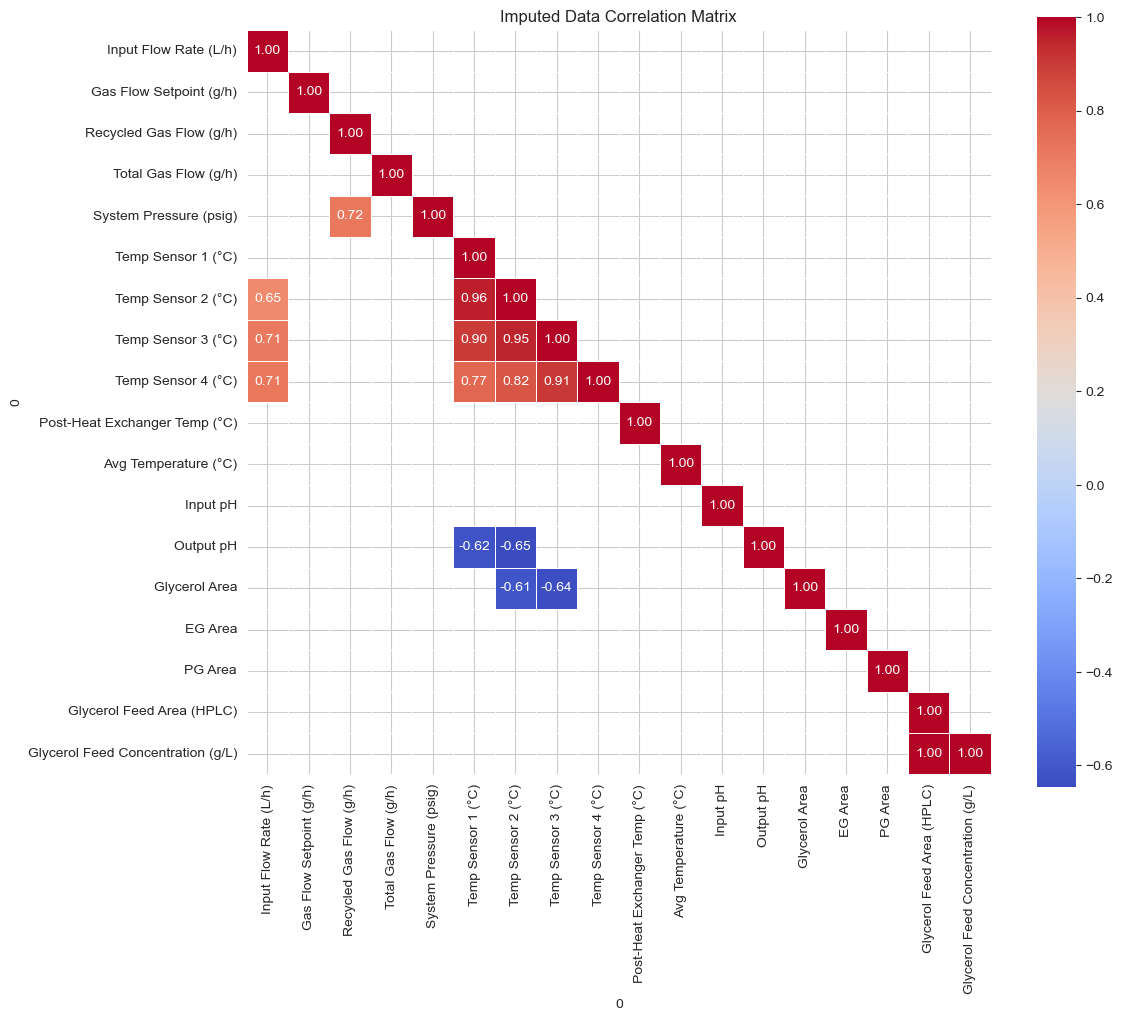

In [117]:
corr = imputed_no_calc_df.corr()
corr_filtered = corr.where((corr > 0.60) | (corr < -0.60))
mask = np.triu(np.ones_like(corr, dtype=bool))
np.fill_diagonal(mask, False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_filtered, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=0.5, mask=mask)
plt.title('Imputed Data Correlation Matrix')
plt.show()

### Box and whisker plot for all features of imputed data

We have earlier seen the histogram distribution of imputed data vs. original data which shows noticeable but not significantly different distribution. Below is the box plot comparison of the imputed data (cream) and orginal data (blue) for all features.

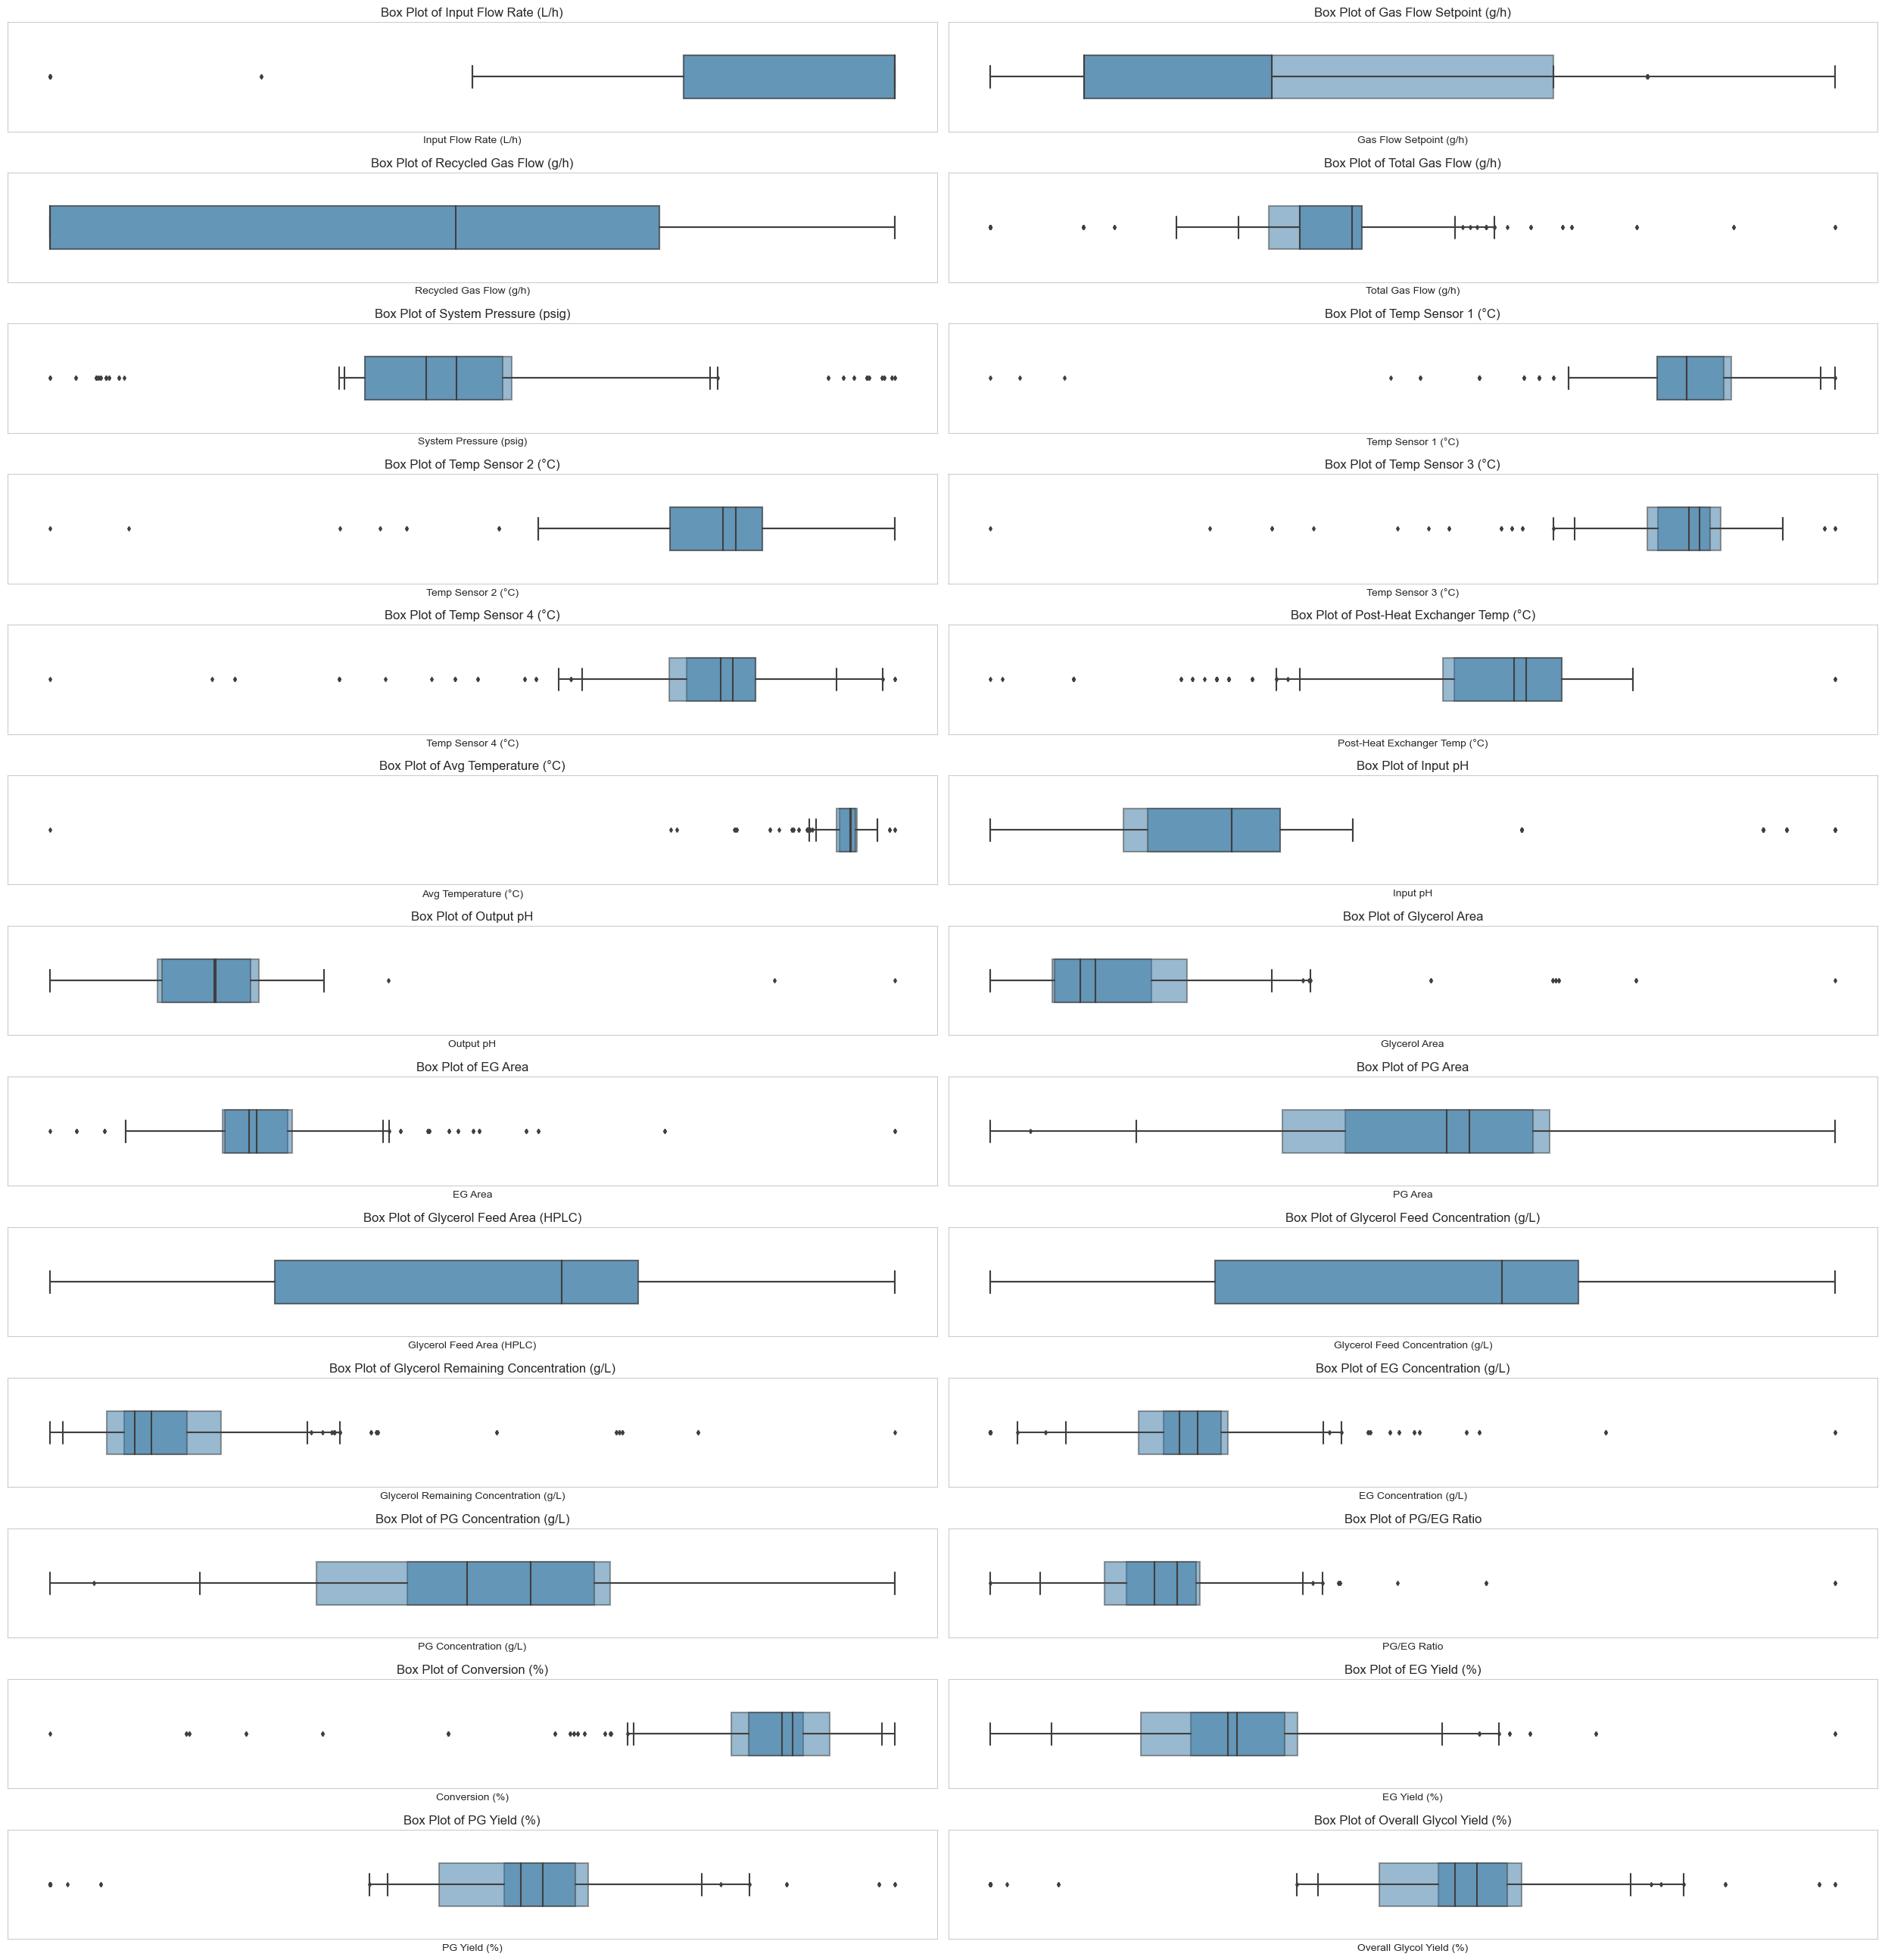

In [118]:
num_features = len(imputed_df.columns)
n_cols = 2
n_rows = (num_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 2))
axes = axes.flatten()

for i, col in enumerate(imputed_df.columns):
    sns.boxplot(x=numerical_df[col], ax=axes[i], width=0.4, fliersize=3, boxprops=dict(alpha=0.5))
    sns.boxplot(x=imputed_df[col], ax=axes[i], width=0.4, fliersize=3, boxprops=dict(alpha=0.5))
    axes[i].set_title(f'Box Plot of {col}')

    # Hide axes
    axes[i].set_xticks([])
    axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Most of the imputed data (cream) is closely aligned with the original, indicating minimal changes post-imputation. There are just a few features with broader spread in the imputed data such as pure H2 gas flow, PG concentration, EG concentration, conversion, EG/PG yield and overall glycol yield. It may seem that the imputed data shows a slighlty different performance metrics than that of the original data.

## EXPORTING THE DATAFRAMES

In [119]:
hydrogen_df.to_pickle("data/hydrogen_df.pkl")
numerical_df.to_pickle("data/numerical_df.pkl")
no_calc_df.to_pickle("data/no_calc_df.pkl")
imputed_df.to_pickle("data/imputed_df.pkl")
imputed_no_calc_df.to_pickle("data/imputed_no_calc_df.pkl")

The following preprocessed datasets will be exported and loaded for model development in the proceeding Jupyter notebooks.